In [1]:
from IPython.display import Markdown, display

In [2]:
display(Markdown("""
<span style="font-size:16px;">

## DSM050 Data Visualisation — Final Coursework Project (CW2)
## The Analysis of Celiac Disease's *Ontological Space*: A BioSNAP- and NetworkX-Based Approach

*Note*: This notebook contains the data processing pipeline, network models, and visualization exports; 
relevant coding references are also included.
It is organized into five sections, each corresponding to a specific research question. 
Comprehensive results, interpretation, and discussion are detailed only in the accompanying PDF report.
"""))


<span style="font-size:16px;">

## DSM050 Data Visualisation — Final Coursework Project (CW2)
## The Analysis of Celiac Disease's *Ontological Space*: A BioSNAP- and NetworkX-Based Approach

*Note*: This notebook contains the data processing pipeline, network models, and visualization exports; 
relevant coding references are also included.
It is organized into five sections, each corresponding to a specific research question. 
Comprehensive results, interpretation, and discussion are detailed only in the accompanying PDF report.


In [3]:
display(Markdown("""
<span style="font-size:16px;">

### Links for Downloading

* **Disease-disease network (DD-Miner):**  
  [https://snap.stanford.edu/biodata/datasets/10006/10006-DD-Miner.html](https://snap.stanford.edu/biodata/datasets/10006/10006-DD-Miner.html)

* **Disease descriptions and synonyms from DO (D-DoMiner):**  
  [https://snap.stanford.edu/biodata/datasets/10021/10021-D-DoMiner.html](https://snap.stanford.edu/biodata/datasets/10021/10021-D-DoMiner.html)

* **Disease descriptions and synonyms from MeSH (D-MeshMiner):**  
  [https://snap.stanford.edu/biodata/datasets/10003/10003-D-MeshMiner.html](https://snap.stanford.edu/biodata/datasets/10003/10003-D-MeshMiner.html)

* **Human Disease Ontology (DO):**  
  [http://purl.obolibrary.org/obo/doid.obo](http://purl.obolibrary.org/obo/doid.obo)

* **Disease-function association network (DF-Miner):**  
  [https://snap.stanford.edu/biodata/datasets/10019/10019-DF-Miner.html](https://snap.stanford.edu/biodata/datasets/10019/10019-DF-Miner.html)

* **Gene Ontology (GO-Basic):**  
  [https://current.geneontology.org/ontology/go-basic.obo](https://current.geneontology.org/ontology/go-basic.obo)

"""))


<span style="font-size:16px;">

### Links for Downloading

* **Disease-disease network (DD-Miner):**  
  [https://snap.stanford.edu/biodata/datasets/10006/10006-DD-Miner.html](https://snap.stanford.edu/biodata/datasets/10006/10006-DD-Miner.html)

* **Disease descriptions and synonyms from DO (D-DoMiner):**  
  [https://snap.stanford.edu/biodata/datasets/10021/10021-D-DoMiner.html](https://snap.stanford.edu/biodata/datasets/10021/10021-D-DoMiner.html)

* **Disease descriptions and synonyms from MeSH (D-MeshMiner):**  
  [https://snap.stanford.edu/biodata/datasets/10003/10003-D-MeshMiner.html](https://snap.stanford.edu/biodata/datasets/10003/10003-D-MeshMiner.html)

* **Human Disease Ontology (DO):**  
  [http://purl.obolibrary.org/obo/doid.obo](http://purl.obolibrary.org/obo/doid.obo)

* **Disease-function association network (DF-Miner):**  
  [https://snap.stanford.edu/biodata/datasets/10019/10019-DF-Miner.html](https://snap.stanford.edu/biodata/datasets/10019/10019-DF-Miner.html)

* **Gene Ontology (GO-Basic):**  
  [https://current.geneontology.org/ontology/go-basic.obo](https://current.geneontology.org/ontology/go-basic.obo)



In [4]:
display(Markdown("""
<span style="font-size:16px;">

### Additional Resources

* **Stanford Network Analysis Project (SNAP):**  
  [https://snap.stanford.edu/)

* **Medical Subject Headings (MeSH) Browser:**  
  [https://meshb.nlm.nih.gov/](https://meshb.nlm.nih.gov/)
  
* **Human Disease Ontology (DOID) Search:**  
  [https://disease-ontology.org/](https://disease-ontology.org/)
  
* **Pronto (Python frontend to ontologies):**  
  [https://github.com/althonos/pronto](https://github.com/althonos/pronto)

  **Gene Ontology and GO Annotations Browser:**  
  [https://www.ebi.ac.uk/QuickGO/)
  
  

"""))


<span style="font-size:16px;">

### Additional Resources

* **Stanford Network Analysis Project (SNAP):**  
  [https://snap.stanford.edu/)

* **Medical Subject Headings (MeSH) Browser:**  
  [https://meshb.nlm.nih.gov/](https://meshb.nlm.nih.gov/)
  
* **Human Disease Ontology (DOID) Search:**  
  [https://disease-ontology.org/](https://disease-ontology.org/)
  
* **Pronto (Python frontend to ontologies):**  
  [https://github.com/althonos/pronto](https://github.com/althonos/pronto)

  **Gene Ontology and GO Annotations Browser:**  
  [https://www.ebi.ac.uk/QuickGO/)
  
  



In [5]:
display(Markdown("""
<span style="font-size:16px;">

### Research Question (RQ) 1

#### Where does celiac disease stand in the *ontological space* defined by the disease–disease network?

"""))


<span style="font-size:16px;">

### Research Question (RQ) 1

#### Where does celiac disease stand in the *ontological space* defined by the disease–disease network?



In [6]:
import networkx as nx
import pandas as pd

In [7]:
#some references for networkx
#https://networkx.org/documentation/stable/index.html
#https://www.geeksforgeeks.org/python/ego-graph-using-networkx-in-python/

#In general, the KEY REFERENCE for implementing networkx codes was:
#Platt, E. L. (2019). Network Science with Python and NetworkX Quick Start Guide: Explore and visualize network data effectively. 
#Birmingham: Packt Publishing.
# for brevity, referenced below as Platt (2019)

In [8]:
#I start with downloading the disease-disease network file which I will also refer to as the "taxonomic space"
#from
#https://snap.stanford.edu/biodata/datasets/10006/10006-DD-Miner.html 
#download
##DD-Miner_miner-disease-disease.tsv.gz


#"This is disease-disease network that contains information on relationships between inherited, 
#developmental, and acquired human diseases. Nodes represent diseases and edges represent associations between them."
#Disease A<-->Disease B...

In [9]:
#reading the gzip file in Python
#https://stackoverflow.com/questions/12902540/read-a-gzip-file-in-python
#tab-separated values (TSV format).

import gzip

with gzip.open("/Users/lucameoli/DD-Miner_miner-disease-disease.tsv.gz", mode="rt") as f:
    file_content_0 = f.read()
    #print(file_content_0)

In [10]:
df = pd.read_csv(
    "/Users/lucameoli/DD-Miner_miner-disease-disease.tsv.gz" #for unweighted disease ontology graphs
)
df.head()

,# Disease(DOID)\tDisease(DOID)
0,DOID:0001816\tDOID:1115
1,DOID:0002116\tDOID:10124
2,DOID:0014667\tDOID:4
3,DOID:0050004\tDOID:10400
4,DOID:0050012\tDOID:934


In [11]:
#Documented Gemini Prompt, correctly parse the dataset and separate columns properly
df = pd.read_csv(
    "/Users/lucameoli/DD-Miner_miner-disease-disease.tsv.gz",
    sep="\t",
    comment="#",
    header=None,
    names=["Disease1", "Disease2"],
    dtype=str,
)
df.head()

,Disease1,Disease2
0,DOID:0001816,DOID:1115
1,DOID:0002116,DOID:10124
2,DOID:0014667,DOID:4
3,DOID:0050004,DOID:10400
4,DOID:0050012,DOID:934


In [12]:
#next, linking DOID to disease name
# for the next line of code I checked also on:
#https://linuskohl.medium.com/extracting-and-linking-ontology-terms-from-text-7806ae8d8189

from pronto import Ontology
# Load the file containing the DO information (OBO flat file)
doid = Ontology("http://purl.obolibrary.org/obo/doid.obo") #DOID= Disease Ontology IDentifier 

In [13]:
#Documented Gemini Prompt, extract disease ontology terms into a Pandas dataframe
import pandas as pd
rows = []

for t in doid.terms():
    # 3. Only keep IDs that start with 'DOID:'
    if t.id.startswith("DOID:"):
        # 4. Add the ID and Name to the list
        rows.append({"DOID": t.id, "Disease_Name": t.name})

df_doid = pd.DataFrame(rows)
df_doid.head()

,DOID,Disease_Name
0,DOID:0001816,angiosarcoma
1,DOID:0002116,pterygium
2,DOID:0014667,disease of metabolism
3,DOID:0040001,shrimp allergy
4,DOID:0040002,aspirin allergy


In [14]:
#here I search for celiac disease DOID 
df_doid.loc[df_doid['Disease_Name']=="celiac disease"]
#DOID:10608 	

,DOID,Disease_Name
7578,DOID:10608,celiac disease


In [15]:
#Next, I work with the Disease descriptions and synonyms data file, D-DoMiner
#the file is of interest as I can find in it the formal diseases attributes (DOID, name, definitions...)
#also for celiac disease

with gzip.open("/Users/lucameoli/D-DoMiner_miner-diseaseDOID.tsv.gz", mode="rt") as f:
    for _ in range(10):  # print only the first 10 lines
        print(f.readline().strip())

# Disease(DOID)	Name	Definition	Synonym
DOID:0001816	angiosarcoma	A malignant vascular tumor that results_in rapidly proliferating, extensively infiltrating anaplastic cells derived_from blood vessels and derived_from the lining of irregular blood-filled spaces. [url:http\://emedicine.medscape.com/article/276512-overview, url:http\://en.wikipedia.org/wiki/Hemangiosarcoma, url:http\://www.ncbi.nlm.nih.gov/pubmed/23327728]	hemangiosarcoma EXACT []
DOID:0002116	pterygium		surfer's eye EXACT []
DOID:0014667	disease of metabolism	A disease that involving errors in metabolic processes of building or degradation of molecules. [url:http\://www.ncbi.nlm.nih.gov/books/NBK22259/]	metabolic disease  EXACT [SNOMEDCT_2005_07_31:75934005]
DOID:0050001	Actinomadura madurae infectious disease
DOID:0050002	Actinomadura pelletieri infectious disease
DOID:0050003	Streptomyces somaliensis infectious disease
DOID:0050004	seminal vesicle acute gonorrhea
DOID:0050007	cutaneous strongyloidiasis	A strongyloidia

In [16]:
#same strategy as above for creating a dataframe
df_1 = pd.read_csv(
    "/Users/lucameoli/D-DoMiner_miner-diseaseDOID.tsv.gz",
    sep="\t",
    comment="#",
    header=None,
    names= ["DOID", "Disease_Name", "Definitions", "Synonyms"],
    dtype=str,
)

df_1.head()

,DOID,Disease_Name,Definitions,Synonyms
0,DOID:0001816,angiosarcoma,A malignant vascular tumor that results_in rap...,hemangiosarcoma EXACT []
1,DOID:0002116,pterygium,NaN,surfer's eye EXACT []
2,DOID:0014667,disease of metabolism,A disease that involving errors in metabolic p...,metabolic disease EXACT [SNOMEDCT_2005_07_31:...
3,DOID:0050001,Actinomadura madurae infectious disease,NaN,NaN
4,DOID:0050002,Actinomadura pelletieri infectious disease,NaN,NaN


In [17]:
#Here I search for the textual definition of celiac disease in D-DoMiner

#for the next code lines I have used also these references:
#https://note.nkmk.me/en/python-pandas-str-contains-match/
#https://pandas.pydata.org/docs/reference/api/pandas.Series.str.contains.html

celiac= df_1[df_1["DOID"].str.contains("celiac|coeliac", case=False, na=False)
    | df_1["Disease_Name"].str.contains("celiac|coeliac", case=False, na=False)
    | df_1["Definitions"].str.contains("celiac|coeliac", case=False, na=False)
    | df_1["Synonyms"].str.contains("celiac|coeliac", case=False, na=False)
]
celiac

,DOID,Disease_Name,Definitions,Synonyms
86,DOID:0050130,osmotic diarrhea,Osmotic diarrhea is a dirrhea where diarrhea o...,NaN
1910,DOID:10608,celiac disease,An autoimmune disease of gastrointestinal trac...,idiopathic steatorrhea EXACT [MTHICD9_2006:579.0]


In [18]:
#Documented Gemini Prompt, view the full text inside long cells
#To view the full text inside long cells (like "Definitions" and "Synonyms") 
pd.set_option("display.max_colwidth", None)
celiac

,DOID,Disease_Name,Definitions,Synonyms
86,DOID:0050130,osmotic diarrhea,"Osmotic diarrhea is a dirrhea where diarrhea occurs when too much water is drawn into the bowels. This can be the result of maldigestion (e.g., pancreatic disease or Coeliac disease), in which the nutrients are left in the lumen to pull in water. Osmotic diarrhea can also be caused by osmotic laxatives (which work to alleviate constipation by drawing water into the bowels). In healthy individuals, too much magnesium or vitamin C or undigested lactose can produce osmotic diarrhea and distention of the bowel. A person who does not have lactose intolerance can have difficulty absorbing lactose after an extraordinarily high intake of dairy products. [url:http\://en.wikipedia.org/wiki/Diarrhea",NaN
1910,DOID:10608,celiac disease,"An autoimmune disease of gastrointestinal tract that is caused by a reaction located_in small intestine to gliadin, a prolamin (gluten protein) found in wheat, and similar proteins found in the crops of the tribe Triticeae. The disease is associated with HLA-DQ gene. It has_symptom abdominal pain, has_symptom constipation, has_symptom diarrhea, has_symptom nausea and vomiting, and has_symptom loss of appetite. [url:http\://digestive.niddk.nih.gov/ddiseases/pubs/celiac/, url:http\://en.wikipedia.org/wiki/Coeliac_disease, url:http\://www.celiac.org/, url:http\://www.mayoclinic.com/health/celiac-disease/DS00319, url:http\://www.nlm.nih.gov/medlineplus/ency/article/000233.htm]",idiopathic steatorrhea EXACT [MTHICD9_2006:579.0]


In [19]:
#To start exploring the taxonomic space of celiac disease, I construct the network graph
#from the dataframe initially derived from DD-Miner.

#Relevant references for next code cells have been found also in the following sources: 
#https://networkx.org/documentation/stable/reference/generated/networkx.convert_matrix.from_pandas_edgelist.html
#and from Chapter 3, Platt (2019) 

G = nx.from_pandas_edgelist(df, source="Disease1", target="Disease2")
#list(G.nodes)

In [20]:
#Documented Gemini Prompt: discussion about properties of network as here created
#by default the network that I have generated is:
#undirected: no causal flow between diseases
#unweighted: the presence of an edge simply indicates a curated biomedical relationship
#nodes in this case will represent diseases in disease-disease network

In [21]:
#sanity check
#In the following code cells, I determine some key network statistics
#I intend to double-check data validity by comparing with the official SNAP source
#https://snap.stanford.edu/biodata/datasets/10006/10006-DD-Miner.html
#definitions of statistics parameters are derived from Platt (2019)

#number_of_edges
len(list(G.edges))
#or G.number_of_edges()

6877

In [22]:
#number_of_nodes
len(list(G.nodes))
#or G.number_of_nodes()

6878

In [23]:
cd= "DOID:10608" #cd = celiac disease
cd in G

True

In [24]:
#checking on celiac disease neighbors
list(G.neighbors(cd))

['DOID:0060031']

In [25]:
df_doid.loc[df_doid['DOID']=="DOID:0060031"]

,DOID,Disease_Name
799,DOID:0060031,autoimmune disease of gastrointestinal tract


In [26]:
#the sole immediate taxonomic parent category of celiac disease in the unweighted disease ontology tree (DD-Miner) is autoimmune 
#disease of gastrointestinal tract (DOID:0060031) --> celiac disease is thus a subtype of autoimmune gastrointestinal disorder

In [27]:
#Documented Gemini Prompt: needed a more efficient strategy to link DOID to disease names
#Optimizing DOID to disease name mapping onto network nodes
# Strategy:
#Map DOIDs to name dictionaries via zip():
# https://www.geeksforgeeks.org/python/zip-in-python/
# Assign attributes to the graph using nx.set_node_attributes():
#https://networkx.org/documentation/stable/reference/generated/networkx.classes.function.set_node_attributes.html

In [28]:
#Documented Gemini Prompt, amend next code 
#zip function to generate associations between DOID and disease name
#name_map_1=zip(df_doid['DOID'], df_doid['Disease_Name'])
#print(list(name_map_1))-->

In [29]:
#Create a standard Python dictionary from your metadata DataFrame mapping the primary key to the target attribute
name_map = dict(zip(df_doid['DOID'], df_doid['Disease_Name']))
#name_map

In [30]:
nx.set_node_attributes(G, name_map, name='disease_name')

In [31]:
print(G.nodes['DOID:10608'],
G.nodes['DOID:0060031'])

{'disease_name': 'celiac disease'} {'disease_name': 'autoimmune disease of gastrointestinal tract'}


In [32]:
#here I continue with some basic visualization for celiac disease in the taxonomic space

In [33]:
%matplotlib inline
import matplotlib.pyplot as plt

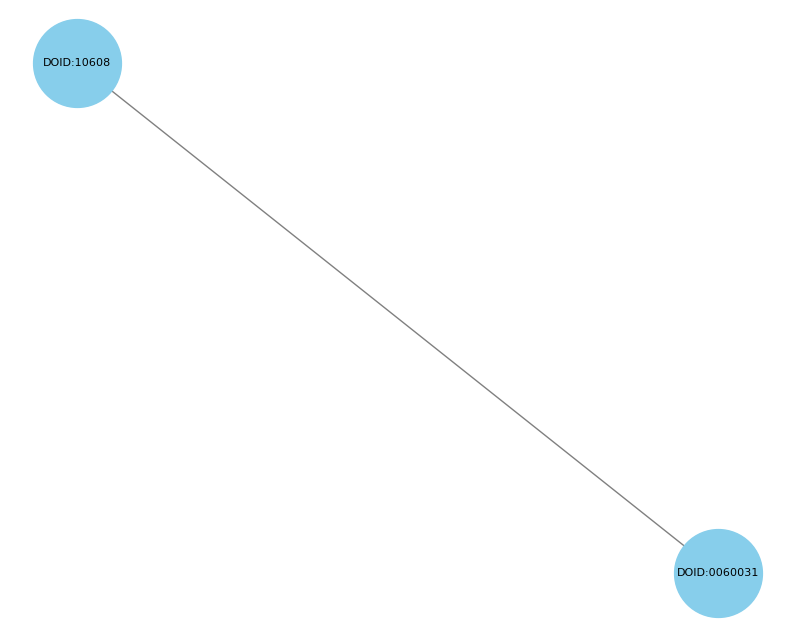

In [34]:
#to attempt a meaningful visualization of celiac disease in the taxonomic space I have to implement 
#a specific approach (e.g., subgraph() method)

#from Chapter 3, Platt (2019): 
#"The subgraph() method of Graph creates a new graph containing a subset of the nodes in
#the original, as well as any edges between those nodes
#Chapter 3, Platt (2019) serves also as the main coding reference for this and next cells

sub_nodes = list(G.neighbors("DOID:10608")) + ["DOID:10608"] 
sub_G = G.subgraph(sub_nodes)

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(sub_G, k=0.5, seed=42)

nx.draw_networkx(
    sub_G,
    pos,
    node_size=4000,
    node_color="skyblue",
    edge_color="gray",
    font_size=8,
    with_labels=True,
)
plt.axis("off")
plt.show()

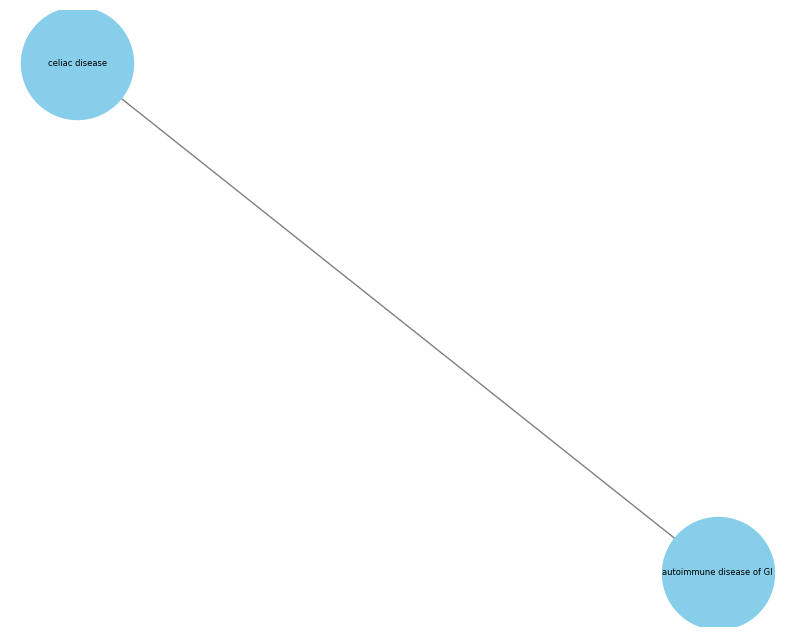

In [35]:
#then I need to replace the DOID values with disease names

sub_nodes = list(G.neighbors("DOID:10608")) + ["DOID:10608"]
sub_G = G.subgraph(sub_nodes)
sublabels=  {
  "DOID:10608": "celiac disease",
    "DOID:0060031": "autoimmune disease of GI"
}

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(sub_G, k=0.5, seed=42)

nx.draw_networkx(
    sub_G,
    pos,
    node_size=6500,
    node_color="skyblue",
    edge_color="gray",
    font_size=6,
    with_labels=True,
    labels=sublabels
   
)
plt.axis("off")
plt.show()

In [36]:
#While this visualization served as the baseline for the "construction" of subsequent graphs, 
#it does not add anything new: celiac disease is already classified as a subtype 
#of autoimmune gastrointestinal disorder. To explore its broader ontological space, 
#I must implement alternative approaches, namely ego networks.
#Definition (Platt, 2019):
#"An ego network (or ego graph) is an induced subgraph centered on a 
#single focal node—the "ego"—consisting of the ego, 
#its immediate neighbors within a specified distance horizon (its "alters"), 
#and all interconnecting edges (cross-links) that exist between those neighbors."

Nodes: 4, Edges: 3


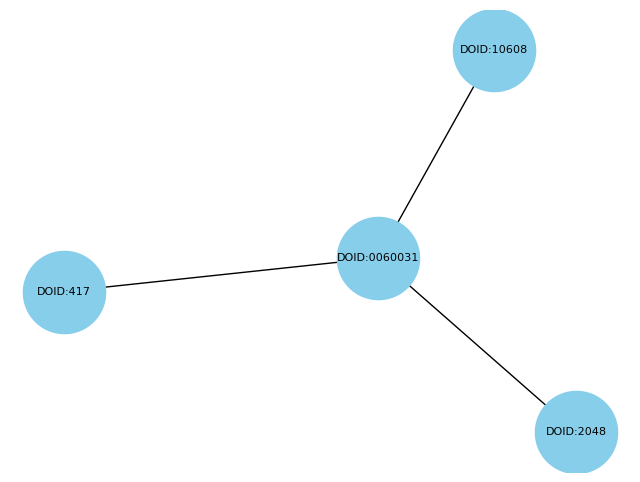

In [37]:
#here I run a 2-hop ego network
sub_G = nx.ego_graph(G, "DOID:10608", radius=2)

print(f"Nodes: {sub_G.number_of_nodes()}, Edges: {sub_G.number_of_edges()}")

# Plot
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(sub_G, seed=42)
nx.draw_networkx(
    sub_G, pos, node_size=3500, node_color="skyblue", font_size=8,

)
plt.axis("off")
plt.show()

In [38]:
#implementing the DOID key (name_map)
nx.set_node_attributes(sub_G, name_map, name='disease_name')

In [39]:
#Getting every node along with its stored info
output=sub_G.nodes(data=True)

#and next transforming the output into a dataframe
#to do this I checked also on:
#type(output) #what is exactly "output"?
#https://stackoverflow.com/questions/35046087/make-networkx-node-attributes-into-pandas-dataframe-columns

pd.DataFrame.from_dict(dict(output), orient='index')

,disease_name
DOID:10608,celiac disease
DOID:2048,autoimmune hepatitis
DOID:0060031,autoimmune disease of gastrointestinal tract
DOID:417,autoimmune disease


Nodes: 4, Edges: 3


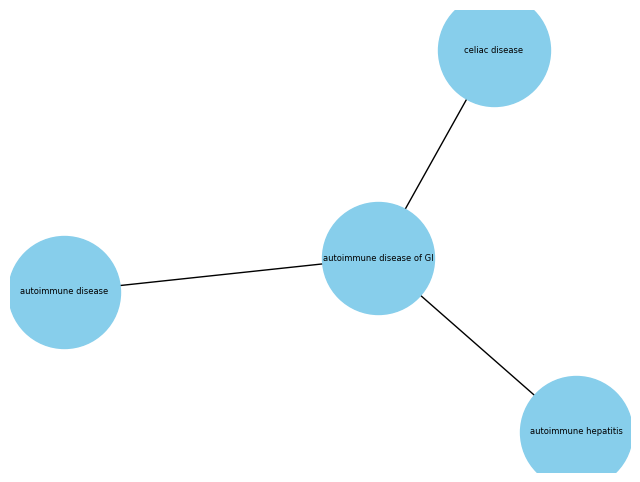

In [40]:
# here the same 2-hop ego network with disease names as sublabels, though
sub_G = nx.ego_graph(G, "DOID:10608", radius=2)

sublabels_1=  {
    "DOID:417": "autoimmune disease",
  "DOID:10608": "celiac disease",
    "DOID:0060031": "autoimmune disease of GI",
    "DOID:2048": "autoimmune hepatitis"
}

print(f"Nodes: {sub_G.number_of_nodes()}, Edges: {sub_G.number_of_edges()}")

# Plot
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(sub_G, seed=42)
nx.draw_networkx(
    sub_G, pos, node_size=6500, node_color="skyblue", font_size=6,
    labels=sublabels_1

)
plt.axis("off")
plt.show()

In [41]:
#again, autoimmune hepatitis emerges as the sole taxonomic sibling 
#located 2 hops away from celiac disease. Although it affects a distinct anatomical 
#site (liver), its placement under "autoimmune disease of gastrointestinal tract" 
#reflects the gut–liver axis and hepatic–intestinal cross-talk (see discussion in the report).

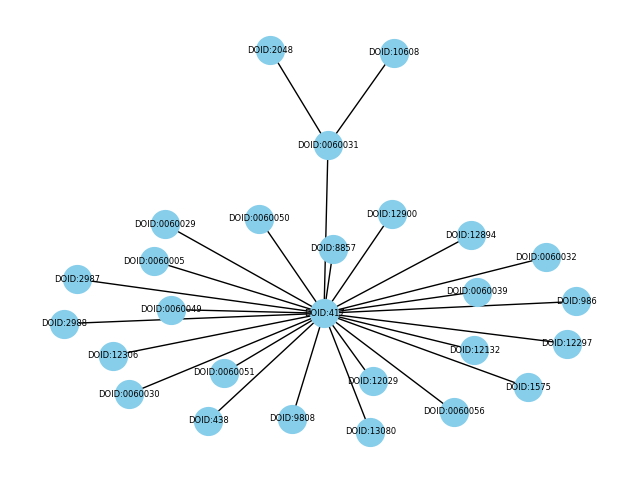

In [42]:
# Here, I construct a 3-hop ego network instead
sub_G = nx.ego_graph(G, "DOID:10608", radius=3)

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(sub_G, seed=42)
nx.draw_networkx(
    sub_G, pos, node_size=400, node_color="skyblue", font_size=6,


)
plt.axis("off")
plt.show()

In [43]:
#visualization not optimal...

In [44]:
print(f"Nodes: {sub_G.number_of_nodes()}, Edges: {sub_G.number_of_edges()}")

Nodes: 27, Edges: 26


In [45]:
# The 3-hop subgraph contains 27 nodes and 26 edges. Let's improve the visualization: 
# also, manually mapping DOID key-value pairs is tedious and inefficient...
#Documented Gemini Prompt: labels Disease Ontology Ego networks, plus visualization improvements

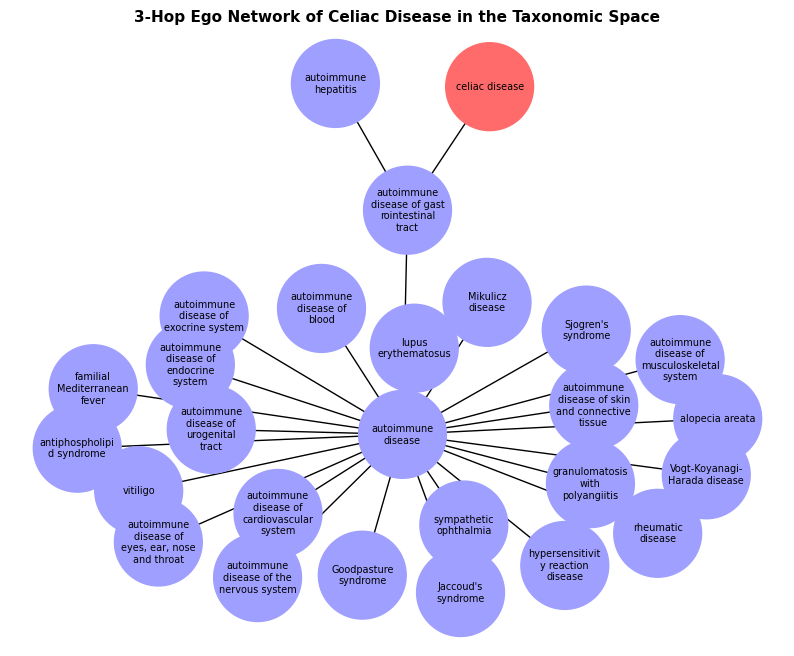

In [46]:
import textwrap

name_dict = dict(zip(df_doid["DOID"], df_doid["Disease_Name"]))
labels = {
    n: textwrap.fill(str(name_dict.get(n) or n), width=15)
    for n in sub_G.nodes()
}



# Plot
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(sub_G, seed=42)


colors = [
    "#FF6B6B" if n == "DOID:10608" else "#9f9fff" for n in sub_G.nodes()
]


nx.draw_networkx(
    sub_G,
    pos,
    node_size=4000,
    node_color=colors,
    font_size=7,
    labels=labels,
)


plt.axis("off")
plt.title("3-Hop Ego Network of Celiac Disease in the Taxonomic Space", fontsize=11, fontweight="bold")


plt.savefig(
    "ego_3_network_plot.png",
    dpi=300,
    bbox_inches="tight",  # Crops outer whitespace directly to the graph elements 
    pad_inches=0,  # Eliminates any padding border around the canvas
      
)

plt.show()

#references of interest for saving the plot were also: 
#https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.savefig.html)
#https://pysql.tecladocode.com/section09/lectures/14_export_image_matplotlib/

In [47]:
#Hop 0 (ego): celiac disease (red node)
#Hop 1 (parent): autoimmune disease of gastrointestinal tract
#Hop 2: autoimmune hepatitis (the sole sibling branching off Hop 1), of biological interest! (see also Seidita et al., PMID: 39796519)
#autoimmune disease; the central grand-parent hub
#Hop 3 (autoimmune cluster): other specialized autoimmune categories radiating off the central autoimmune disease hub



#Autoimmune hepatitis is classified under the "autoimmune disease of gastrointestinal tract" umbrella.
#Embryologically, the liver and gastrointestinal tract belong to the same digestive system.
#In fact, the epithelial linings of the digestive tract, liver, gallbladder, and pancreas all derive from the endoderm
#(Bhatia et al., https://www.ncbi.nlm.nih.gov/books/NBK537172/).
#Other autoimmune conditions—such as Sjögren's syndrome, rheumatoid arthritis, or systemic lupus erythematosus—
#require traversing 3 or more hops through the central grandparent hub (autoimmune disease) to be reached.
#This may appear as an artifact of the ontological tree, and to some extent it probably is.
#However, Experimental Liver Cirrhosis ranks as celiac disease's #1 functional partner! (see subsequent sections).
#These results emphasize the biological importance of the gut–liver axis;
#for instance, patients with celiac disease face a significantly higher risk of concurrent autoimmune liver disease
# (Rubio-Tapia et al., PMID: 17969053).



In [48]:
display(Markdown("""
<span style="font-size:16px;">

### RQ 2

#### Which cellular and molecular processes directly characterize celiac disease, and how do they shape its functional connections to other diseases?

"""))


<span style="font-size:16px;">

### RQ 2

#### Which cellular and molecular processes directly characterize celiac disease, and how do they shape its functional connections to other diseases?



In [49]:
#In order to address this question, I will use the SNAP Disease-Function network
#association network (DF_Miner) along with the bipartite affiliation and projection
#methods implemented in NetworkX

In [50]:
#Most of the codes were adapeted from Platt (2019), Chapter 4:
#Also in the same chapter is reported:
#"Affiliation networks are useful for representing many-to-many relationships. For example,
#a movie can contain many actors, and an actor can appear in many movies."
#For my work, this translates into:
#A disease can be associated with different biological processes (i.e., gene ontology terms), 
#and any biological process can appear in many different diseases.
#Rather than being used solely to generate graphs, this approach can be used to inspect 
#the GO terms associated with celiac disease and downstream connections! 

In [51]:
#from
#https://snap.stanford.edu/biodata/datasets/10019/10019-DF-Miner.html
#download
##DF-Miner_miner-disease-function.tsv.gz


#This is a disease-function association network that contains information on relationships between diseases and cellular functions. 
#...Nodes represent diseases and functions, and edges indicate associations between them"
#Disease_A <---> GO_X <---> Disease_B...

In [52]:
with gzip.open("/Users/lucameoli/DF-Miner_miner-disease-function.tsv.gz", mode="rt") as f:
    file_content_1 = f.read()
    print(file_content_1)

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [53]:
#Documented Gemini Prompt, avoid data rate exceeded
import gzip

with gzip.open("/Users/lucameoli/DF-Miner_miner-disease-function.tsv.gz", mode="rt") as f:
    for _ in range(10):  # print only the first 10 lines
        print(f.readline().strip())

# MESH_ID	GO_ID
MESH:D000037	GO:0009257
MESH:C536409	GO:0009257
MESH:D009436	GO:0009257
MESH:D000860	GO:0009258
MESH:D008106	GO:0009258
MESH:D009765	GO:0009258
MESH:D056486	GO:0006653
MESH:D015785	GO:0006653
MESH:D057130	GO:0006653


In [54]:
df_2 = pd.read_csv(
    "/Users/lucameoli/DF-Miner_miner-disease-function.tsv.gz",
    sep="\t",
    comment="#",
    header=None,
    names= ["MESH_ID", "GO_ID"],
    dtype=str,
)

df_2.head()

,MESH_ID,GO_ID
0,MESH:D000037,GO:0009257
1,MESH:C536409,GO:0009257
2,MESH:D009436,GO:0009257
3,MESH:D000860,GO:0009258
4,MESH:D008106,GO:0009258


In [55]:
B = nx.from_pandas_edgelist(df_2, source="MESH_ID", target="GO_ID")

In [56]:
#Assessing molecular processes directly characterizing celiac disease

#Specifically, here I extract celiac disease associated GO terms.

#Before any projection (see next), I verify that graph B is strictly bipartite
#this ensures that Disease and Biological Function nodes remain disjoint
#what does that mean?
#B is organized in the following way:
#Disease_A <---> GO_X <---> Disease_B
#Diseases A and B connect solely through intermediate GO pathways!

In [57]:
#here I check whether my B is bipartite
from networkx.algorithms import bipartite
bipartite.is_bipartite(G) #my dataset is bipartite

True

In [58]:
#sanity check, n nodes and edges 

In [59]:
len(list(B.edges))

802760

In [60]:
len(list(B.nodes))

20549

In [61]:
#Here I check the cellular and molecular processes celiac disease connect to
sub_B_1hop = nx.ego_graph(B, "MESH:D002446", radius=1)
print(sub_B_1hop)

Graph with 292 nodes and 291 edges


In [62]:
#Celiac disease is a multi-systemic autoimmune condition that engages 291 distinct cellular and molecular processes

In [63]:
#extracting the GO terms associated (directly) with celiac diseases
celiac_right_nodes = [n for n in sub_B_1hop.nodes() if n != "MESH:D002446"]

print("Celiac Function Count:", len(celiac_right_nodes))
print(celiac_right_nodes[:10])

Celiac Function Count: 291
['GO:0005634', 'GO:0000981', 'GO:0043277', 'GO:0072673', 'GO:0032395', 'GO:0051260', 'GO:0046642', 'GO:0048011', 'GO:0034616', 'GO:0045334']


In [64]:
from pronto import Ontology
import pandas as pd

go = Ontology("go-basic.obo")

rows = []
for g in go.terms():
    # 3. Only keep IDs that start with 'GO:'
    if g.id.startswith("GO:"):
        # 4. Add the ID and Name to the list
        rows.append({"GO": g.id, "Biological Function": g.name})

df_go = pd.DataFrame(rows)
df_go.head()

,GO,Biological Function
0,GO:0000001,mitochondrion inheritance
1,GO:0000002,obsolete mitochondrial genome maintenance
2,GO:0000003,obsolete reproduction
3,GO:0000005,obsolete ribosomal chaperone activity
4,GO:0000006,high-affinity zinc transmembrane transporter activity


In [65]:
#celiac_right_nodes, linking GO and and biological functions
#references for the next lines
#https://www.ionos.com/digitalguide/websites/web-development/python-pandas-dataframe-isin/
#https://www.geeksforgeeks.org/python/python-pandas-dataframe-isin/
df_celiac_functions = df_go[df_go["GO"].isin(celiac_right_nodes)]
df_celiac_functions.head(10)

,GO,Biological Function
100,GO:0000122,negative regulation of transcription by RNA polymerase II
112,GO:0000139,Golgi membrane
117,GO:0000146,microfilament motor activity
134,GO:0000166,nucleotide binding
391,GO:0002250,adaptive immune response
515,GO:0002376,immune system process
517,GO:0002381,immunoglobulin production involved in immunoglobulin-mediated immune response
587,GO:0002455,humoral immune response mediated by circulating immunoglobulin
638,GO:0002507,tolerance induction
678,GO:0002548,monocyte chemotaxis


In [66]:
#Appendix 1 Celiac disease and GO terms
#used also following references
#https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_excel.html
#(index: bool, default True. Write row names (index))
#https://stackoverflow.com/questions/22089317/export-from-pandas-to-excel-without-row-names-index


df_celiac_functions.to_excel("Appendix _1_Celiac Disease and GO Terms.xlsx", index=False)

In [67]:
#Documented Gemini Prompt, detect primary functional categories (Appendix 1)

# Celiac Disease functional profile (291 GO terms) partitioned into 5 core mechanistic pillars:
#These follow along a few associated examples
#
# 1. Adaptive & innate immunity:
#    - GO:0002474 (antigen processing and presentation of peptide antigen via MHC class II)
#    - GO:0042110 (T cell activation)
#
# 2. Epithelial barrier integrity and cell junctions:
#    - GO:0005911 (cell-cell junction)
#    - GO:0005925 (focal adhesion)
#
# 3. Cytotoxicity, apoptosis and mucosal remodeling:
#    - GO:0001913 (T cell mediated cytotoxicity)
#    - GO:0006915 (apoptotic process)
#
# 4. Nutrient absorption and solute transport:
#    - GO:0050892 (intestinal absorption)
#    - GO:0031526 (brush border membrane)
#
# 5. Housekeeping machinery:
#    - GO:0005524 (ATP binding)
#    - GO:0005739 (mitochondrion)

In [68]:
#The next sections pertain to celiac disease functional connections
#most of the codes for this parts were adapted from Platt (2019), Chapter 4

In [69]:
#first of all I have to isolate the left nodes
mesh_terms=df_2["MESH_ID"].unique()
#mesh_terms
#reminder: df_2 derived from DF-Miner!

In [70]:
from networkx.algorithms import bipartite

# creating a co-affiliation network
B = nx.from_pandas_edgelist(df_2, source="MESH_ID", target="GO_ID") #done also above!
# creating a left projection
G_proj=bipartite.weighted_projected_graph(B, mesh_terms) 
#This collapses the bipartite graph down to disease only nodes
#MESH (for Disease_A)<---> GO_X <---> MESH(for Disease_B...)-->
#MESH (for Disease_A) <--->MESH (for Disease_B)...
#For every pair of MESH terms that share at least one GO term, G_proj creates an edge between them
#edge weight (w)= number of GO terms a pair has in common

In [71]:
#***For brevity and clarity, In the next comments I will refer to "MeSH disease terms" simply as "diseases"***

In [72]:
#first off all, to focus on celiac disease I run an ego_graph extracted from G_proj...
#To this end I have considered the networkx documentation: 
#https://networkx.org/documentation/stable/reference/generated/networkx.generators.ego.ego_graph.html
cd_ego=nx.ego_graph(G_proj, n="MESH:D002446" , radius=1, center=True, undirected=False, distance=None)
#so I get a subgraph of G_proj consisting of celiac disease plus every disease directly connected to it (radius=1 = immediate neighbors only)

#Documented Gemini Prompt: is the original edge weight (number of shared GO terms between diseases) preserved by setting distance= none?

In [73]:
num_neighbors = cd_ego.number_of_nodes() 
#num_neighbors = cd_ego.number_of_nodes()-1 #(without celiac disease)
num_edges = cd_ego.number_of_edges()

print(num_neighbors, num_edges)
#the disease nodes: 4289 diseases (no CD included) are directly connected with celiac disease (they share at least one GO term)

4290 8571520


In [74]:
#the number of nodes and edges is extremely high...not ideal to be as such represented

#this code is adpated from Platt (2019), Chapter 4, but, as anticipated is too heavy
#plt.figure(figsize=(30, 30))
#pos = nx.spring_layout(cd_ego, k=0.5, seed=42)
#nx.draw_networkx_edges(cd_ego, pos, width=3, alpha=0.2, edge_color="gray")
#nx.draw_networkx_nodes(cd_ego, pos, node_color="#9f9fff", node_size=6000)
#nx.draw_networkx_labels(cd_ego, pos, font_size=9, font_family="sans-serif")

#plt.axis("off")
#plt.tight_layout()
#plt.show()

#--> need a different strategy

In [75]:
#Documented Gemini Prompt, GO connections: extracting only heavily connected conditions and strategy options

#I thus go for two strategies: one for analysing the data and one for visualizing the results

#define weight threshold -->
# strategy 1
#wieght threshold relatively low--> extract top disease connections for celiac disease 

#strategy 2
#weight threshold relatively high --> visualize

In [76]:
#To begin with, I make a dataframe from the cd_ego which is centered around the celiac disease 
#https://networkx.org/documentation/stable/reference/generated/networkx.convert_matrix.to_pandas_edgelist.html
#reminder: cd_ego=nx.ego_graph(G_proj, n="MESH:D002446" , radius=1, center=True, undirected=False, distance=None

df_edges = nx.to_pandas_edgelist(cd_ego)
threshold = 15 #arbitrary value
df_filtered_edges = df_edges[df_edges["weight"] >= threshold]
df_filtered_edges.head()
#however this contains again different targets...and not only celiac disease
#I want to retrieve data only about celiac disease!

,source,target,weight
3,MESH:D000037,MESH:D020326,21
8,MESH:D000037,MESH:D006528,123
9,MESH:D000037,MESH:C538212,16
15,MESH:D000037,MESH:D010009,54
21,MESH:D000037,MESH:D011928,17


In [77]:
#Documented Gemini Prompt: filtering the edge list down to only the connections involving celiac disease

#Consistently setting celiac disease as the target
cd_id = "MESH:D002446"

df_celiac_only = df_filtered_edges[
    (df_filtered_edges["source"] == cd_id)
    | (df_filtered_edges["target"] == cd_id)
]
df_celiac_only.head()

,source,target,weight
2945,MESH:D000037,MESH:D002446,36
7198,MESH:C536409,MESH:D002446,21
11473,MESH:D009436,MESH:D002446,123
15760,MESH:D000860,MESH:D002446,104
20045,MESH:D008106,MESH:D002446,256


In [78]:
#sorting values by weight
#https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_values.html

df_celiac_only.sort_values(by="weight", ascending=False)

,source,target,weight
20045,MESH:D008106,MESH:D002446,256
220345,MESH:D011471,MESH:D002446,250
72910,MESH:D001943,MESH:D002446,236
68638,MESH:D001321,MESH:D002446,232
2006984,MESH:D001172,MESH:D002446,231
...,...,...,...
2202666,MESH:D002446,MESH:C562718,15
2203228,MESH:D002446,MESH:300200,15
2204922,MESH:D002446,MESH:613575,15
2203444,MESH:D002446,MESH:C567027,15


In [79]:
#I need a key for MESH terms, namely the D_MeshMiner
#https://snap.stanford.edu/biodata/datasets/10003/10003-D-MeshMiner.html
#"This is a dataset of disease synopses, including disease names, definitions, and synonyms"

df_mesh_key = pd.read_csv(
    "/Users/lucameoli/D-MeshMiner_miner-disease.tsv.gz",
    sep="\t",
    comment="#",
    header=None,
    names= ["MESH_ID", "Disease_Name", "Definitions", "Synonyms"],
    dtype=str,
)

df_mesh_key
df_mesh_key.drop(["Synonyms"], axis=1, inplace= True) #keep definitions
df_mesh_key

,MESH_ID,Disease_Name,Definitions
0,MESH:C538288,10p Deletion Syndrome (Partial),NaN
1,MESH:C535484,13q deletion syndrome,NaN
2,MESH:C579849,15q24 Microdeletion,NaN
3,MESH:C579850,16p11.2 Deletion Syndrome,NaN
4,MESH:C567076,"17,20-Lyase Deficiency, Isolated",NaN
...,...,...,...
11327,MESH:C536729,Zunich neuroectodermal syndrome,NaN
11328,MESH:C536730,Zuska's Disease,NaN
11329,MESH:C565223,Zygodactyly 1,NaN
11330,MESH:D015051,Zygomatic Fractures,Fractures of the zygoma.


In [80]:
#Documented Gemini Prompt: this merge is WRONG! 
#this merge is WRONG! 

#df_merge = df_celiac_only.merge(
    #df_mesh_key[["MESH_ID", "Disease_Name", "Definitions"]],
    #left_on="source",
    #right_on="MESH_ID",
    #how="left",
#)
#df_merge

#The resulting file has in fact inaccurate mappings
#many rows label the neighbor disease as celiac disease itself instead of the actual connected partner! How to fix it?

In [81]:
df_celiac_only["Partner_ID"] = df_celiac_only.apply(
    lambda row: row["target"] if row["source"] == cd_id else row["source"],
    axis=1,
)

/var/folders/_s/p9gxcg_901xc40yd_syh_7_w0000gn/T/ipykernel_2062/570195323.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_celiac_only["Partner_ID"] = df_celiac_only.apply(


In [82]:
#Retaining a single definition per disease to prevent duplicate rows during merge
mesh_key_unique = df_mesh_key.drop_duplicates(subset=["MESH_ID"])

# Merging on Partner_ID so the table resolves the partner disease's name and definition
df_merge = df_celiac_only.merge(
    mesh_key_unique[["MESH_ID", "Disease_Name", "Definitions"]],
    left_on="Partner_ID",
    right_on="MESH_ID",
    how="left",
)

In [83]:
df_final_merge = (
    df_merge[["Partner_ID", "Disease_Name", "weight", "Definitions"]]
    .rename(columns={"Partner_ID": "source"})
    .sort_values(by="weight", ascending=False)
    .reset_index(drop=True)
)

In [84]:
df_final_merge.to_excel("Appendix_2_Disease by Weight.xlsx", index=False)
df_final_merge.head(10)

,source,Disease_Name,weight,Definitions
0,MESH:D008106,"Liver Cirrhosis, Experimental",256,Experimentally induced chronic injuries to the parenchymal cells in the liver to achieve a model for LIVER CIRRHOSIS.
1,MESH:D011471,Prostatic Neoplasms,250,Tumors or cancer of the PROSTATE.
2,MESH:D001943,Breast Neoplasms,236,Tumors or cancer of the human BREAST.
3,MESH:D001321,Autistic Disorder,232,A disorder beginning in childhood. It is marked by the presence of markedly abnormal or impaired development in social interaction and communication and a markedly restricted repertoire of activity and interest. Manifestations of the disorder vary greatly depending on the developmental level and chronological age of the individual. (DSM-V)
4,MESH:D001172,"Arthritis, Rheumatoid",231,"A chronic systemic disease, primarily of the joints, marked by inflammatory changes in the synovial membranes and articular structures, widespread fibrinoid degeneration of the collagen fibers in mesenchymal tissues, and by atrophy and rarefaction of bony structures. Etiology is unknown, but autoimmune mechanisms have been implicated."
5,MESH:D008175,Lung Neoplasms,227,Tumors or cancer of the LUNG.
6,MESH:D002277,Carcinoma,223,"A malignant neoplasm made up of epithelial cells tending to infiltrate the surrounding tissues and give rise to metastases. It is a histological type of neoplasm but is often wrongly used as a synonym for 'cancer.' (From Dorland, 27th ed)"
7,MESH:D009362,Neoplasm Metastasis,222,The transfer of a neoplasm from one organ or part of the body to another remote from the primary site.
8,MESH:D013274,Stomach Neoplasms,219,Tumors or cancer of the STOMACH.
9,MESH:D008545,Melanoma,219,"A malignant neoplasm derived from cells that are capable of forming melanin, which may occur in the skin of any part of the body, in the eye, or, rarely, in the mucous membranes of the genitalia, anus, oral cavity, or other sites. It occurs mostly in adults and may originate de novo or from a pigmented nevus or malignant lentigo. Melanomas frequently metastasize widely, and the regional lymph nodes, liver, lungs, and brain are likely to be involved. The incidence of malignant skin melanomas is rising rapidly in all parts of the world. (Stedman, 25th ed; from Rook et al., Textbook of Dermatology, 4th ed, p2445)"


In [85]:
#The top 10 disease most heavily connected to celiac disease (by shared GO terms)
#span diverse clinical classes, including neoplasms (e.g., Carcinoma, Breast Neoplasms),
#systemic autoimmune disorders (Rheumatoid Arthritis),and neurodevelopmental conditions (Autistic Disorder).
#Interestingly, while earlier literature reported co-occurring autoimmunity and celiac disease
#in autistic individuals (e.g., Lau et al., PMID: 23823064), recent 
#evidence suggests that a definitive clinical association remains unconfirmed (e.g., Zambrano et al., PMID: 37400878).
#It is also interesting to observe that inflammatory bowel diseases such as ulcerative colitis and Crohn's disease, 
#"immune-mediated diseases characterized by chronic intestinal inflammation" (Pascual et al., PMID: 24803796) share less GO terms
#see next code

In [86]:
#Crohn Disease MESH ID
df_mesh_key.loc[
    df_mesh_key["Disease_Name"].str.contains("crohn", case=False, na=False)
]

,MESH_ID,Disease_Name,Definitions
2735,MESH:D003424,Crohn Disease,"A chronic transmural inflammation that may involve any part of the DIGESTIVE TRACT from MOUTH to ANUS, mostly found in the ILEUM, the CECUM, and the COLON. In Crohn disease, the inflammation, extending through the intestinal wall from the MUCOSA to the serosa, is characteristically asymmetric and segmental. Epithelioid GRANULOMAS may be seen in some patients."
8309,MESH:C536215,Pediatric Crohn's disease,NaN


In [87]:
#Crohn Disease  "weight"
df_final_merge[df_final_merge['source']=="MESH:D003424"]

,source,Disease_Name,weight,Definitions
63,MESH:D003424,Crohn Disease,175,"A chronic transmural inflammation that may involve any part of the DIGESTIVE TRACT from MOUTH to ANUS, mostly found in the ILEUM, the CECUM, and the COLON. In Crohn disease, the inflammation, extending through the intestinal wall from the MUCOSA to the serosa, is characteristically asymmetric and segmental. Epithelioid GRANULOMAS may be seen in some patients."


In [88]:
#Ulcerative colitis, MESH ID
df_mesh_key[
    df_mesh_key["Disease_Name"].str.contains(
        "Colitis, Ulcerative", case=False, na=False
    )
]

,MESH_ID,Disease_Name,Definitions
2376,MESH:D003093,"Colitis, Ulcerative","Inflammation of the COLON that is predominantly confined to the MUCOSA. Its major symptoms include DIARRHEA, rectal BLEEDING, the passage of MUCUS, and ABDOMINAL PAIN."


In [89]:
##Ulcerative colitis, weight
df_final_merge[df_final_merge['source']== "MESH:D003093"]

,source,Disease_Name,weight,Definitions
35,MESH:D003093,"Colitis, Ulcerative",192,"Inflammation of the COLON that is predominantly confined to the MUCOSA. Its major symptoms include DIARRHEA, rectal BLEEDING, the passage of MUCUS, and ABDOMINAL PAIN."


In [90]:
#strategy 2: visualizing results

In [91]:
#To simplify the visualization of the network connecting celiac disease and related diseases via GO terms,
#I select "heavily" connected nodes using an edge-weight threshold of 200
#(where weight represents again the count of shared GO terms between celiac disease and partner diseases!)

#Documented Gemini Prompt, extracting "heavy nodes by weight

cd_id = "MESH:D002446"
threshold = 200 #diseases that share at least 200 GO terms

#loop
heavy_nodes = []
for neighbour, attr in cd_ego[cd_id].items():
    if attr.get("weight", 0) >= threshold:
        heavy_nodes.append(neighbour)

In [92]:
selected_nodes = [cd_id] + heavy_nodes #here, it is a good idea including celiac disease! Otherwise the 
#visualization is incomplete...
sub_heavy = cd_ego.subgraph(selected_nodes) #ego network including celiac disease plus its "heavy" (≥200) neighbors


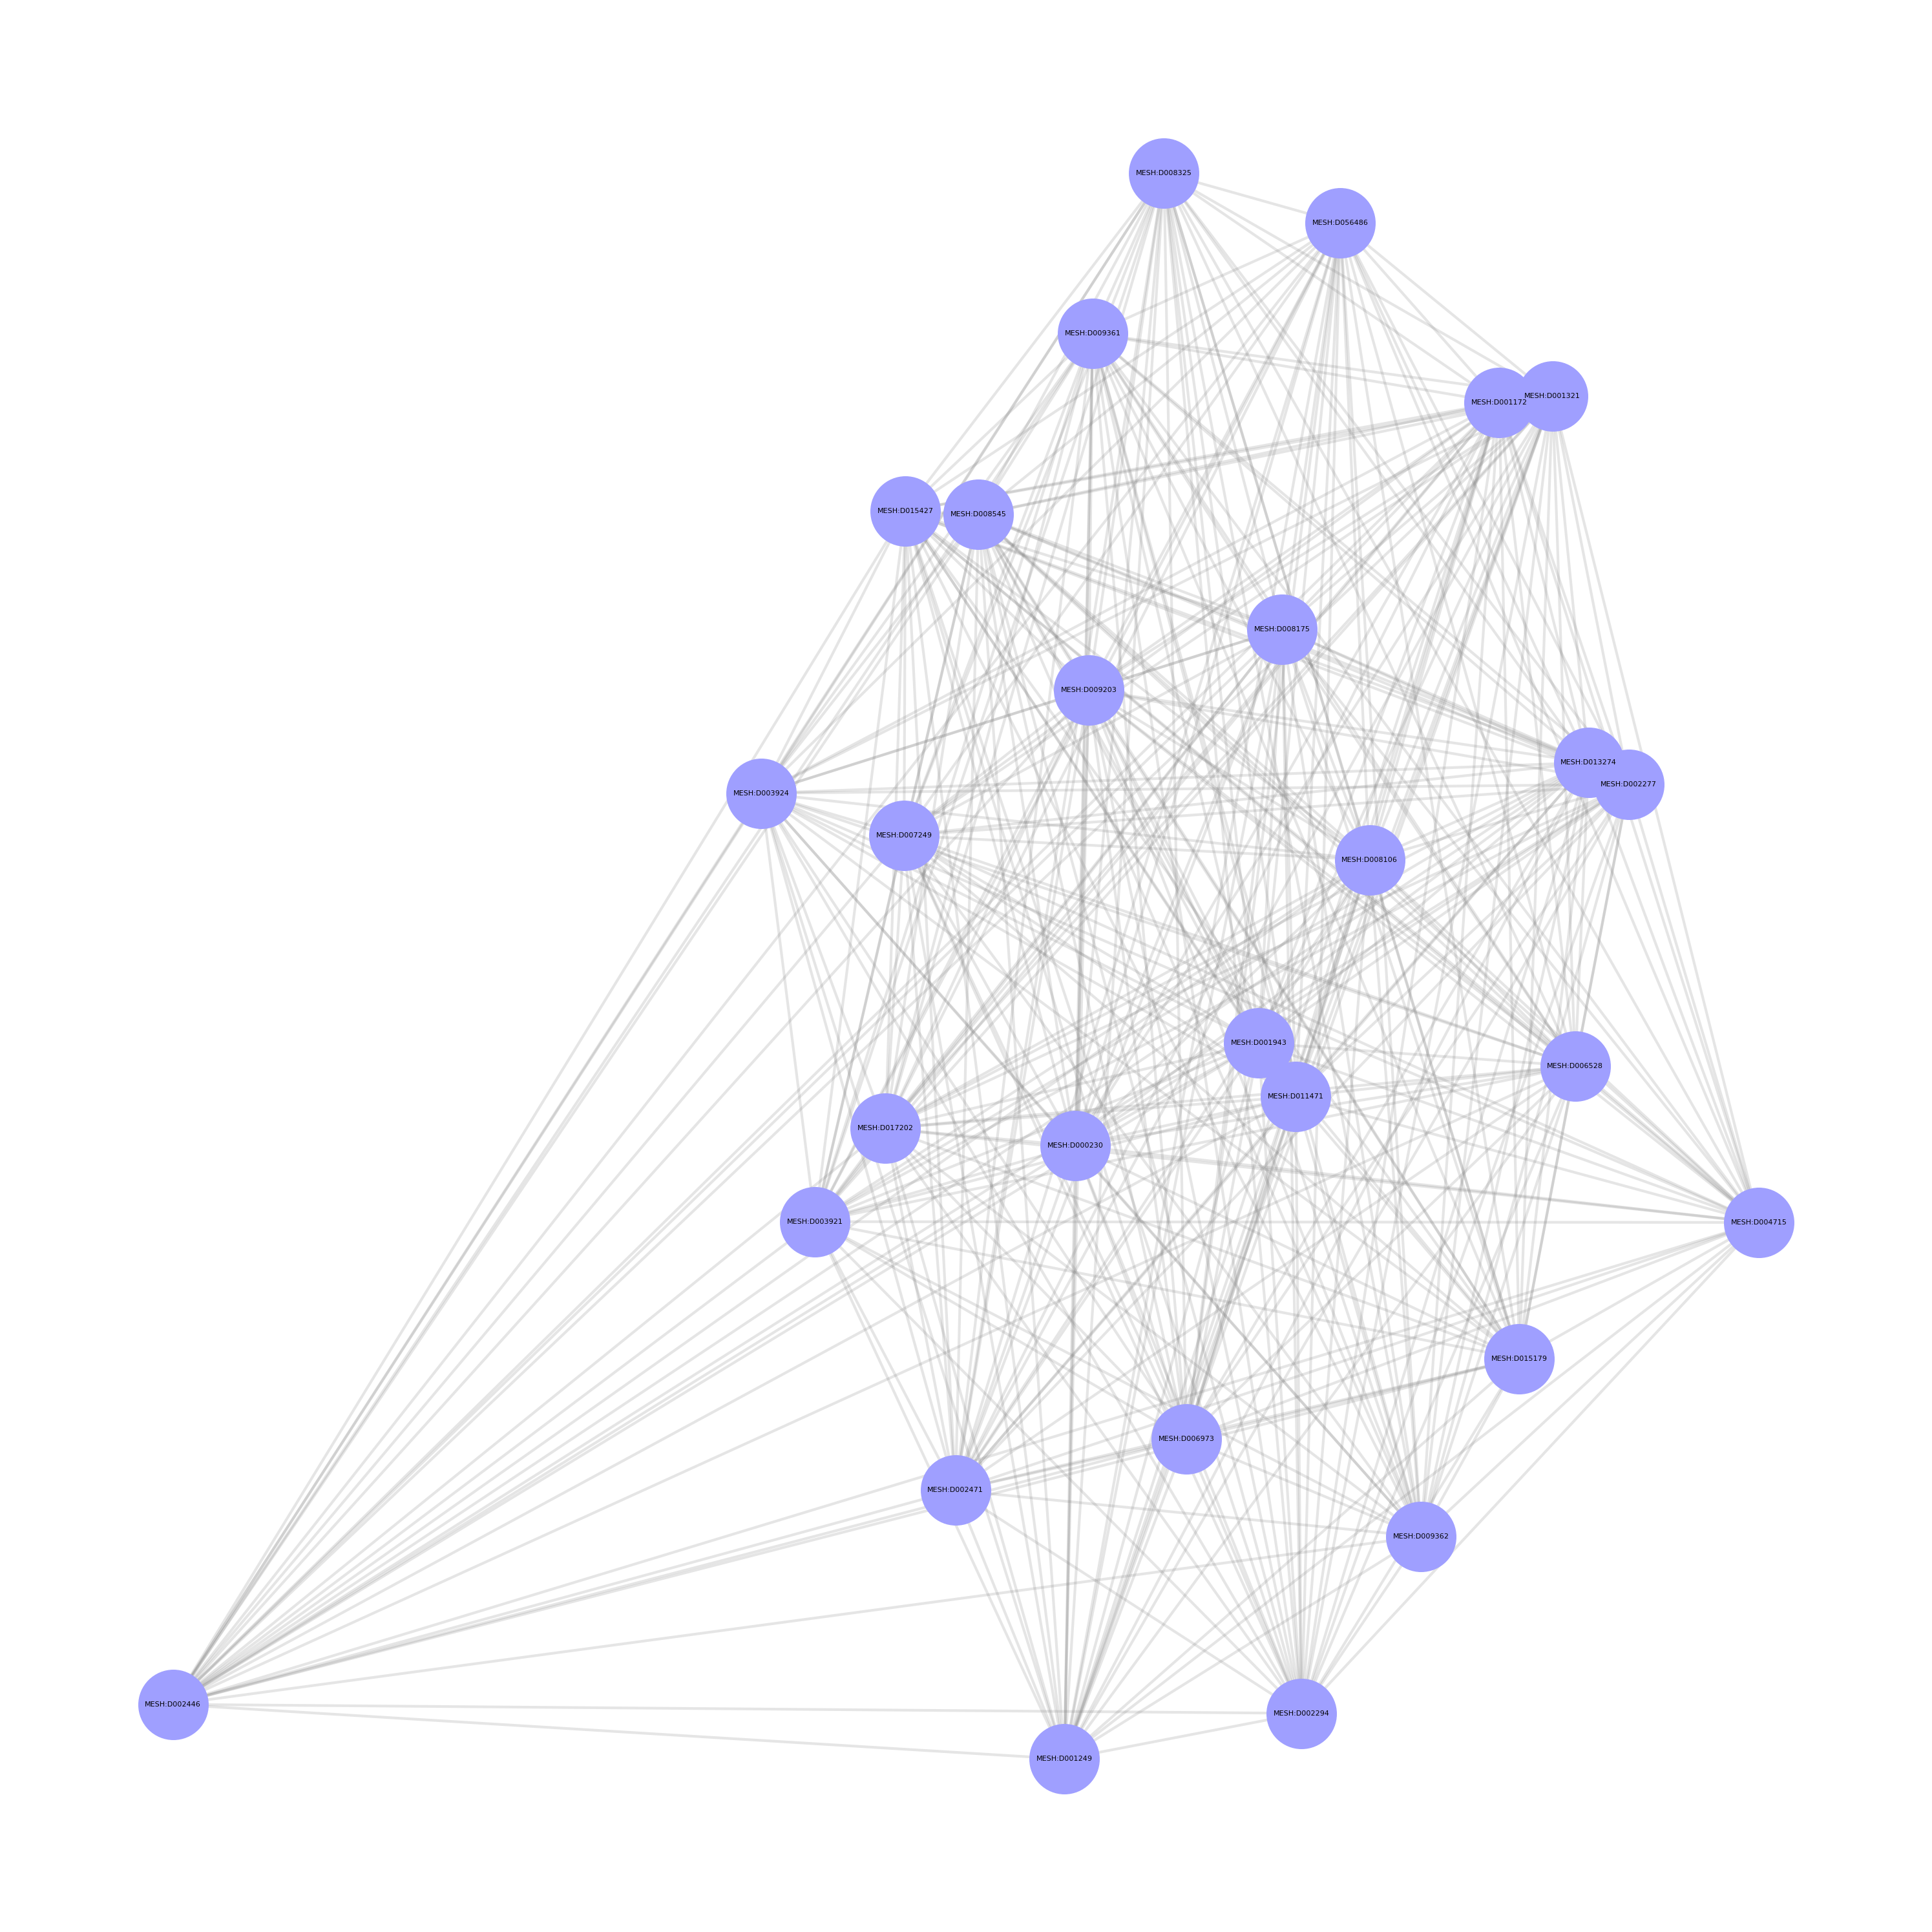

In [93]:
#code is eesentially adapted from Platt (2019), Chapter 4

plt.figure(figsize=(30, 30))
pos = nx.spring_layout(sub_heavy, k=0.5, seed=42)
nx.draw_networkx_edges(
    sub_heavy, pos, width=3, alpha=0.2, edge_color="gray"
)
nx.draw_networkx_nodes(sub_heavy, pos, node_color="#9f9fff", node_size=6000)
nx.draw_networkx_labels(sub_heavy, pos, font_size=8)
plt.axis("off")
plt.tight_layout()
plt.show()

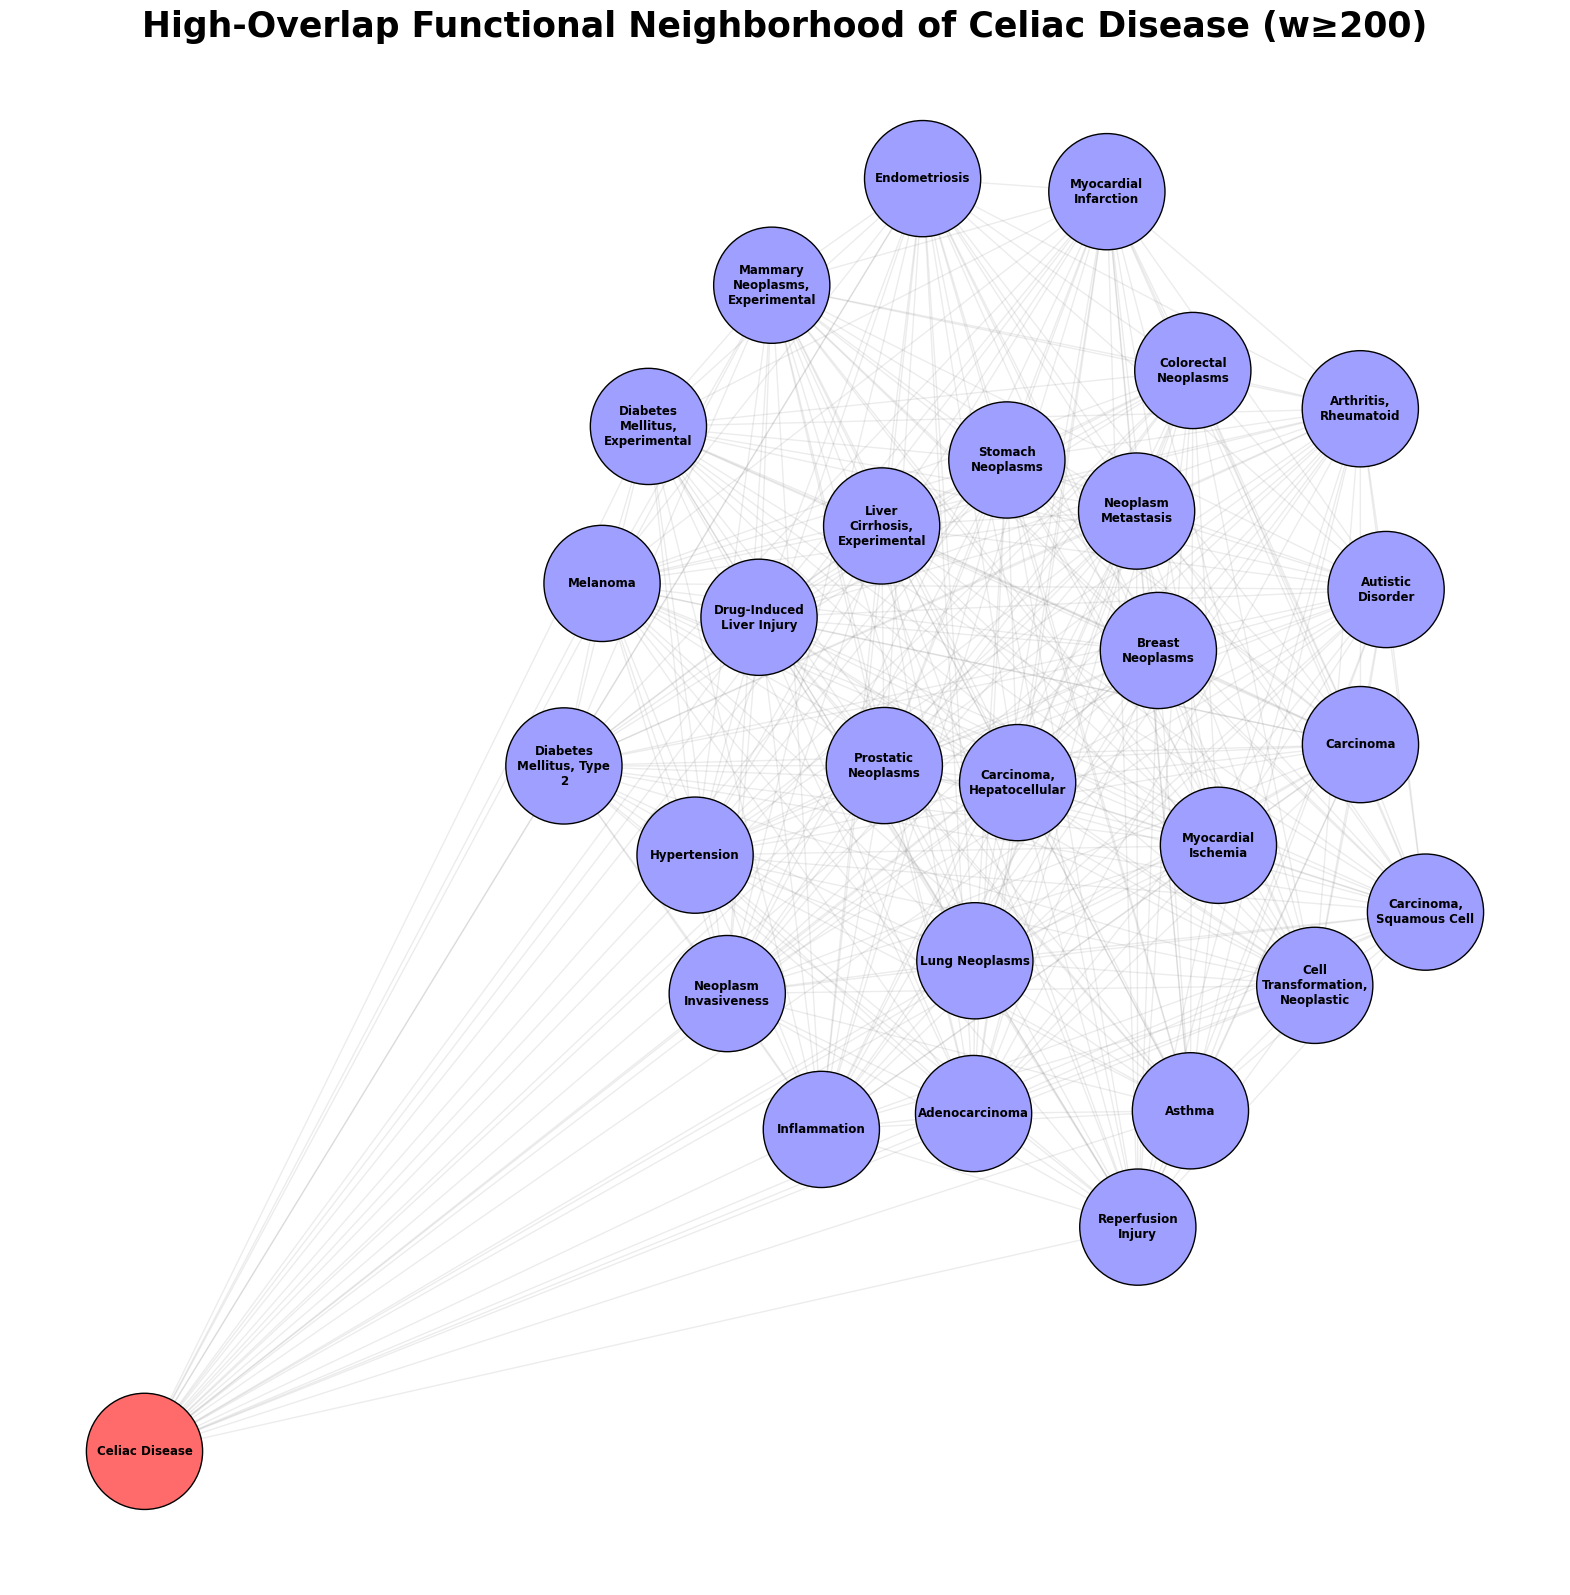

In [94]:
#EXPORT
#Documented Gemini Prompt, improving visualization
import textwrap

#name_dict, same strategy as for  3-hop subgraph 
name_dict = dict(zip(df_mesh_key["MESH_ID"], df_mesh_key["Disease_Name"]))
labels = {
    n: textwrap.fill(str(name_dict.get(n, n)), width=15)
    for n in sub_heavy.nodes()
}

plt.figure(figsize=(20, 20))
pos = nx.spring_layout(sub_heavy, k=0.9, seed=42)


nx.draw_networkx_edges(
    sub_heavy, pos, width=1, alpha=0.15, edge_color="gray"
)


colors = [
    "#FF6B6B" if n == "MESH:D002446" else "#9f9fff" for n in sub_heavy.nodes()
]
nx.draw_networkx_nodes(
    sub_heavy, pos, node_color=colors, node_size=7000, edgecolors="black"
)

# 4. Multiline labels fit neatly inside standard node sizes
nx.draw_networkx_labels(
    sub_heavy, pos, labels=labels, font_size=8.5, font_weight="bold"
)
plt.title("High-Overlap Functional Neighborhood of Celiac Disease (w≥200)", fontsize=25, fontweight="bold")
plt.axis("off")

plt.savefig(
    "Celiac disease and heavy neighbors.png",
    dpi=300,
    bbox_inches="tight",  
    pad_inches=0,  
      
)

plt.show()

In [95]:
heavy_nodes
heavy_key = df_mesh_key[df_mesh_key["MESH_ID"].isin(heavy_nodes)]
heavy_key

,MESH_ID,Disease_Name,Definitions
252,MESH:D000230,Adenocarcinoma,A malignant epithelial tumor with a glandular organization.
873,MESH:D001172,"Arthritis, Rheumatoid","A chronic systemic disease, primarily of the joints, marked by inflammatory changes in the synovial membranes and articular structures, widespread fibrinoid degeneration of the collagen fibers in mesenchymal tissues, and by atrophy and rarefaction of bony structures. Etiology is unknown, but autoimmune mechanisms have been implicated."
922,MESH:D001249,Asthma,"A form of bronchial disorder with three distinct components: airway hyper-responsiveness (RESPIRATORY HYPERSENSITIVITY), airway INFLAMMATION, and intermittent AIRWAY OBSTRUCTION. It is characterized by spasmodic contraction of airway smooth muscle, WHEEZING, and dyspnea (DYSPNEA, PAROXYSMAL)."
1025,MESH:D001321,Autistic Disorder,A disorder beginning in childhood. It is marked by the presence of markedly abnormal or impaired development in social interaction and communication and a markedly restricted repertoire of activity and interest. Manifestations of the disorder vary greatly depending on the developmental level and chronological age of the individual. (DSM-V)
1400,MESH:D001943,Breast Neoplasms,Tumors or cancer of the human BREAST.
1564,MESH:D002277,Carcinoma,"A malignant neoplasm made up of epithelial cells tending to infiltrate the surrounding tissues and give rise to metastases. It is a histological type of neoplasm but is often wrongly used as a synonym for 'cancer.' (From Dorland, 27th ed)"
1579,MESH:D006528,"Carcinoma, Hepatocellular","A primary malignant neoplasm of epithelial liver cells. It ranges from a well-differentiated tumor with EPITHELIAL CELLS indistinguishable from normal HEPATOCYTES to a poorly differentiated neoplasm. The cells may be uniform or markedly pleomorphic, or form GIANT CELLS. Several classification schemes have been suggested."
1599,MESH:D002294,"Carcinoma, Squamous Cell","A carcinoma derived from stratified SQUAMOUS EPITHELIAL CELLS. It may also occur in sites where glandular or columnar epithelium is normally present. (From Stedman, 25th ed)"
1802,MESH:D002471,"Cell Transformation, Neoplastic","Cell changes manifested by escape from control mechanisms, increased growth potential, alterations in the cell surface, karyotypic abnormalities, morphological and biochemical deviations from the norm, and other attributes conferring the ability to invade, metastasize, and kill."
2411,MESH:D015179,Colorectal Neoplasms,Tumors or cancer of the COLON or the RECTUM or both. Risk factors for colorectal cancer include chronic ULCERATIVE COLITIS; FAMILIAL POLYPOSIS COLI; exposure to ASBESTOS; and irradiation of the CERVIX UTERI.


In [96]:
#Appendix 3, celiac disease and diseases that share at least 200 GO terms with it
heavy_key.to_excel("Appendix _3_Celiac Disease and Heavy Nodes.xlsx", index=False)
#It is interesting to observe that Diabetes Mellitus, Type 2, and not Type 1 Diabetes
# (the autoimmune form of diabetes), appears in this list!

In [97]:
df_mesh_key[
    df_mesh_key["Disease_Name"].str.contains(
        "Diabetes Mellitus, Type 1", case=False, na=False
    )
]

,MESH_ID,Disease_Name,Definitions
3147,MESH:D003922,"Diabetes Mellitus, Type 1","A subtype of DIABETES MELLITUS that is characterized by INSULIN deficiency. It is manifested by the sudden onset of severe HYPERGLYCEMIA, rapid progression to DIABETIC KETOACIDOSIS, and DEATH unless treated with insulin. The disease may occur at any age, but is most common in childhood or adolescence."


In [98]:
#Diabetes Mellitus, Type 1, weight
df_final_merge[df_final_merge['source']== "MESH:D003922"]

,source,Disease_Name,weight,Definitions
81,MESH:D003922,"Diabetes Mellitus, Type 1",166,"A subtype of DIABETES MELLITUS that is characterized by INSULIN deficiency. It is manifested by the sudden onset of severe HYPERGLYCEMIA, rapid progression to DIABETIC KETOACIDOSIS, and DEATH unless treated with insulin. The disease may occur at any age, but is most common in childhood or adolescence."


In [99]:
display(Markdown("""
<span style="font-size:16px;">

### RQ 3

#### How does celiac disease behave across taxonomic versus functional network spaces, and what can be learned from this "structural" transition?


"""))


<span style="font-size:16px;">

### RQ 3

#### How does celiac disease behave across taxonomic versus functional network spaces, and what can be learned from this "structural" transition?




In [100]:
#To addrees this question, I will look at the the node degree of my networks.
#In #https://networkx.org/documentation/stable/reference/classes/generated/networkx.Graph.degree.html is reported that:
#The node degree is the number of edges adjacent to the node. 
#The weighted node degree is the sum of the edge weights for edges incident to that node.

#k degree- taxonomic space
G = nx.from_pandas_edgelist(df, source="Disease1", target="Disease2")
k_tax = G.degree("DOID:10608")  #1
k_tax

1

In [101]:
#Celiac disease has exactly 1 edge, not a surprise...see also "3-Hop Ego Network of Celiac Disease in the Disease Ontology" graph....

In [102]:
# k degree or node strength- functional space
#in Wikipedia paragraph on "Measures for weighted networks" one can also read
#that the node strength is thhe sum of weights attached to ties belonging to a node

#https://en.wikipedia.org/wiki/Weighted_network

G_proj=bipartite.weighted_projected_graph(B, mesh_terms)
k_func = G_proj.degree("MESH:D002446", weight="weight")  # Sum of all shared GO terms (weights), node strength
k_func

123202

In [103]:
#In the projected functional network, celiac Disease is connected to 4.289 other diseases 
#(num_neighbors = cd_ego.number_of_nodes()-1= 4290-1 = 4289 #(-1: without celiac disease))
#with a cumulative strength of 123,202 shared pathway links...
#While formal taxonomy compartmentalizes celiac disease as an "isolated disease"
#its underlying molecular machinery is "reused" across several organs and diseases

In [104]:
display(Markdown("""
<span style="font-size:16px;">

### RQ 4

#### How does celiac disease compare with Crohn's disease?

"""))


<span style="font-size:16px;">

### RQ 4

#### How does celiac disease compare with Crohn's disease?



In [105]:
#This comparison is particularly compelling because Crohn's Disease is an immune-mediated disorder 
#characterized by chronic intestinal inflammation, sharing key commonalities with celiac disease 
#such as clinical heterogeneity and overlapping symptomatology (e.g., diarrhea, abdominal pain, 
# and refractory iron-deficiency anemia).
#Specifically, I intend to inspect the local network centered on either celiac disease or 
#Crohn's Disease, considering the heavy connections established above for celiac disease (w >= 200) 
#and evaluating the corresponding approach for Crohn's Disease.
#To this end, I will use first nx.draw_networkx_edges to render only the edges of the subgraphs and then build on this 
#https://networkx.org/documentation/stable/reference/generated/networkx.drawing.nx_pylab.draw_networkx_edges.html
#the reference for these codes is in Platt (2019), Chapter 6

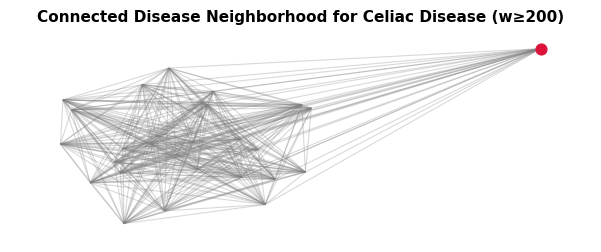

In [106]:
#only edges
%matplotlib inline
import matplotlib.pyplot as plt
import networkx as nx


plt.figure(figsize=(7.5, 2.75))


pos = nx.spring_layout(sub_heavy, seed=42)
#pos = nx.shell_layout(sub_heavy, nlist=[[cd_id], heavy_nodes]) interesting altenrative visualization


nx.draw_networkx_edges(sub_heavy, pos, alpha=0.3, width=0.8, edge_color="gray")



nx.draw_networkx_nodes(sub_heavy, pos, nodelist=[cd_id], node_size=60, node_color="crimson")
#nx.draw_networkx_labels(sub_heavy, pos, labels={cd_id: "Celiac disease"}, font_size=9, font_weight="bold")


plt.title("Connected Disease Neighborhood for Celiac Disease (w≥200)", fontsize=11, fontweight="bold")
plt.axis("off")

plt.savefig(
    "Connected Disease Neighborhood for Celiac Disease.png",
    dpi=300,
    bbox_inches="tight",  
    pad_inches=0,  
      
)

plt.show()

In [107]:
#Documented Gemini Prompt, improving visualization for Connected Disease Neighborhoods

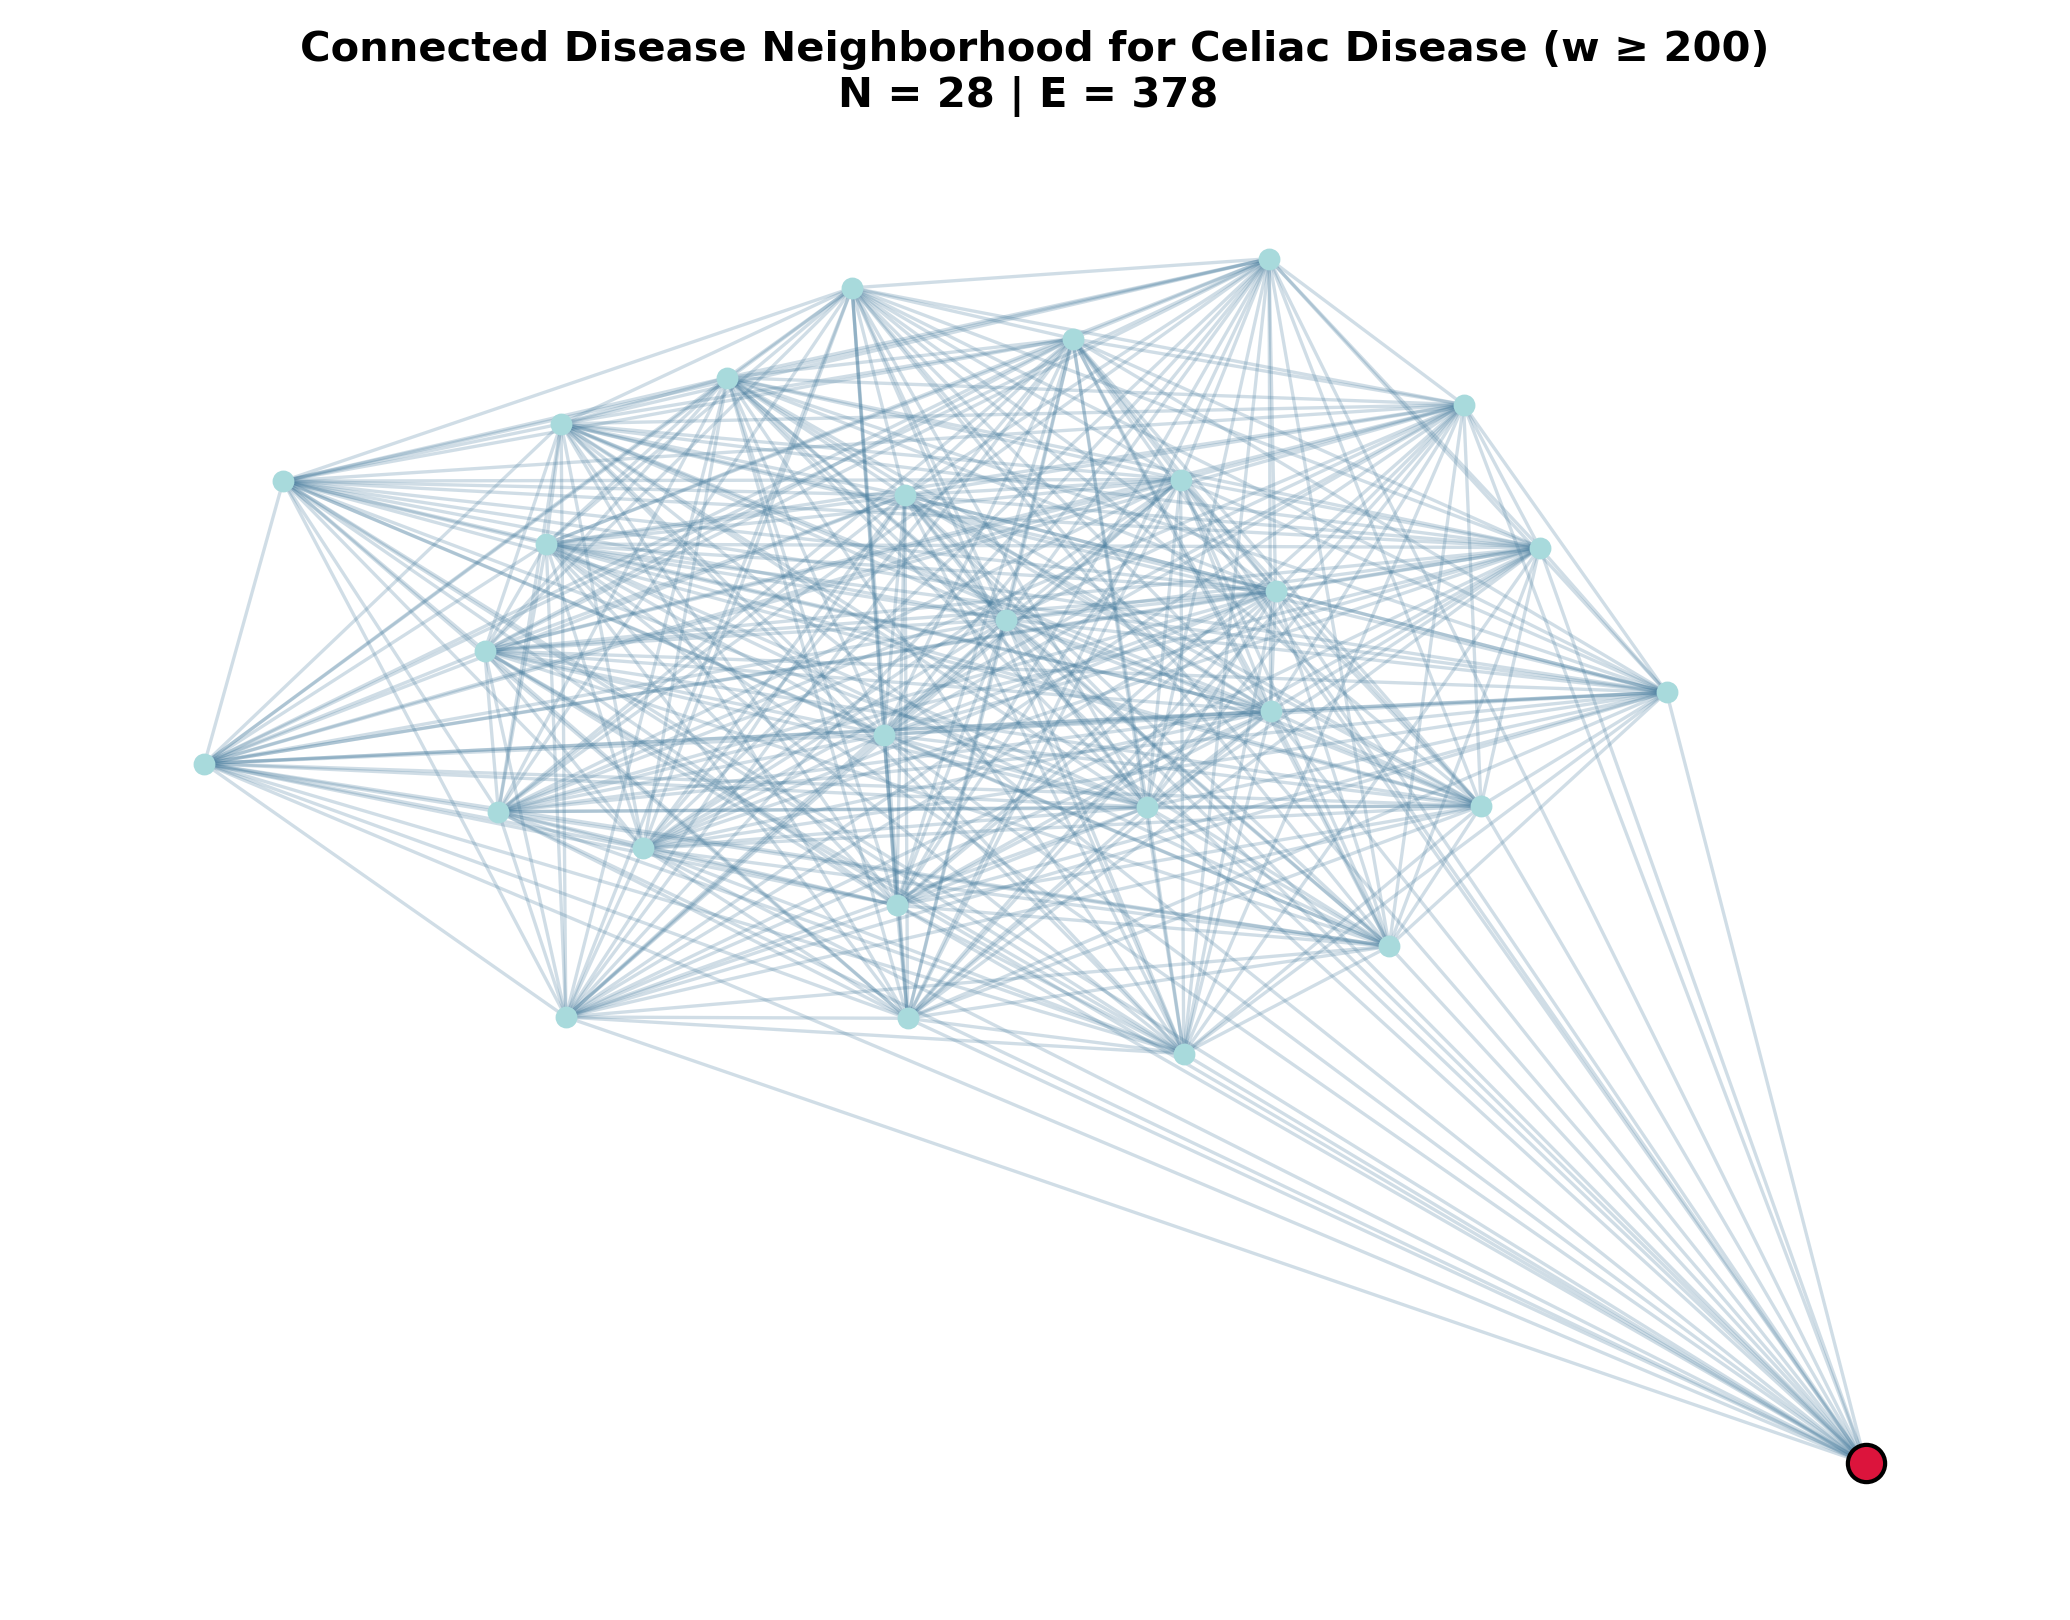

In [108]:
import matplotlib.pyplot as plt
import networkx as nx

fig, ax = plt.subplots(figsize=(7, 5.5), dpi=300)

# Layout
pos_cd = nx.spring_layout(sub_heavy, seed=42, k=0.6)

# Edges
nx.draw_networkx_edges(
    sub_heavy, pos_cd, ax=ax, alpha=0.25, width=0.8, edge_color="#457B9D"
)

# Background nodes
nx.draw_networkx_nodes(
    sub_heavy,
    pos_cd,
    ax=ax,
    nodelist=[n for n in sub_heavy if n != "MESH:D002446"],
    node_size=18,
    node_color="#A8DADC",
)

# Focal node (Celiac Disease)
nx.draw_networkx_nodes(
    sub_heavy,
    pos_cd,
    ax=ax,
    nodelist=["MESH:D002446"],
    node_size=80,
    node_color="crimson",
    edgecolors="black",
)

ax.set_title(
    f"Connected Disease Neighborhood for Celiac Disease (w ≥ 200)\nN = {sub_heavy.number_of_nodes()} | E = {sub_heavy.number_of_edges()} ",
    fontsize=10,
    fontweight="bold",
)
ax.axis("off")

plt.tight_layout()
plt.savefig("Connected Disease Neighborhood for Celiac Disease_I.png", dpi=300)
plt.show()

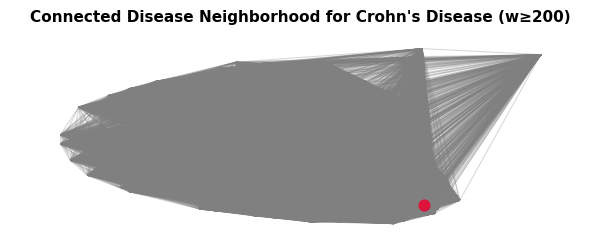

In [109]:
#For global Crohn disease netowrk, i simply adapted previous code(s)

crd_id = "MESH:D003424"
crd_ego = nx.ego_graph(G_proj, n=crd_id, radius=1, center=True, undirected=False,
    distance=None,)
# threshold >= 200 GO pathways
threshold = 200
heavy_nodes_crd = []
for neighbour_crd, attr in crd_ego[crd_id].items():
    if attr.get("weight", 0) >= threshold:
        heavy_nodes_crd.append(neighbour_crd)
#subgraph (Crohn's + heavy neighbors)
selected_nodes_crd = [crd_id] + heavy_nodes_crd
sub_heavy_crd = crd_ego.subgraph(selected_nodes_crd)
plt.figure(figsize=(7.5, 2.75))
pos = nx.spring_layout(sub_heavy_crd, seed=42)
#pos = nx.shell_layout(sub_heavy_crd, nlist=[[crd_id], heavy_nodes_crd]) #hairball! 
# edges only
nx.draw_networkx_edges(
    sub_heavy_crd,
    pos,
    alpha=0.3,
    width=0.8,
    edge_color="gray",
)

# highlight and label Crohn's disease node
nx.draw_networkx_nodes(sub_heavy_crd, pos, nodelist=[crd_id], node_size=60, node_color="crimson")
#nx.draw_networkx_labels(sub_heavy_crd, pos, labels={crd_id: "Crohn's disease"}, font_size=9, font_weight="bold")
plt.title("Connected Disease Neighborhood for Crohn's Disease (w≥200)", fontsize=11, fontweight="bold")
plt.axis("off")

plt.savefig(
    "Connected Disease Neighborhood for Crohn's Disease.png",
    dpi=300,
    bbox_inches="tight",  
    pad_inches=0,  
      
)

plt.show()

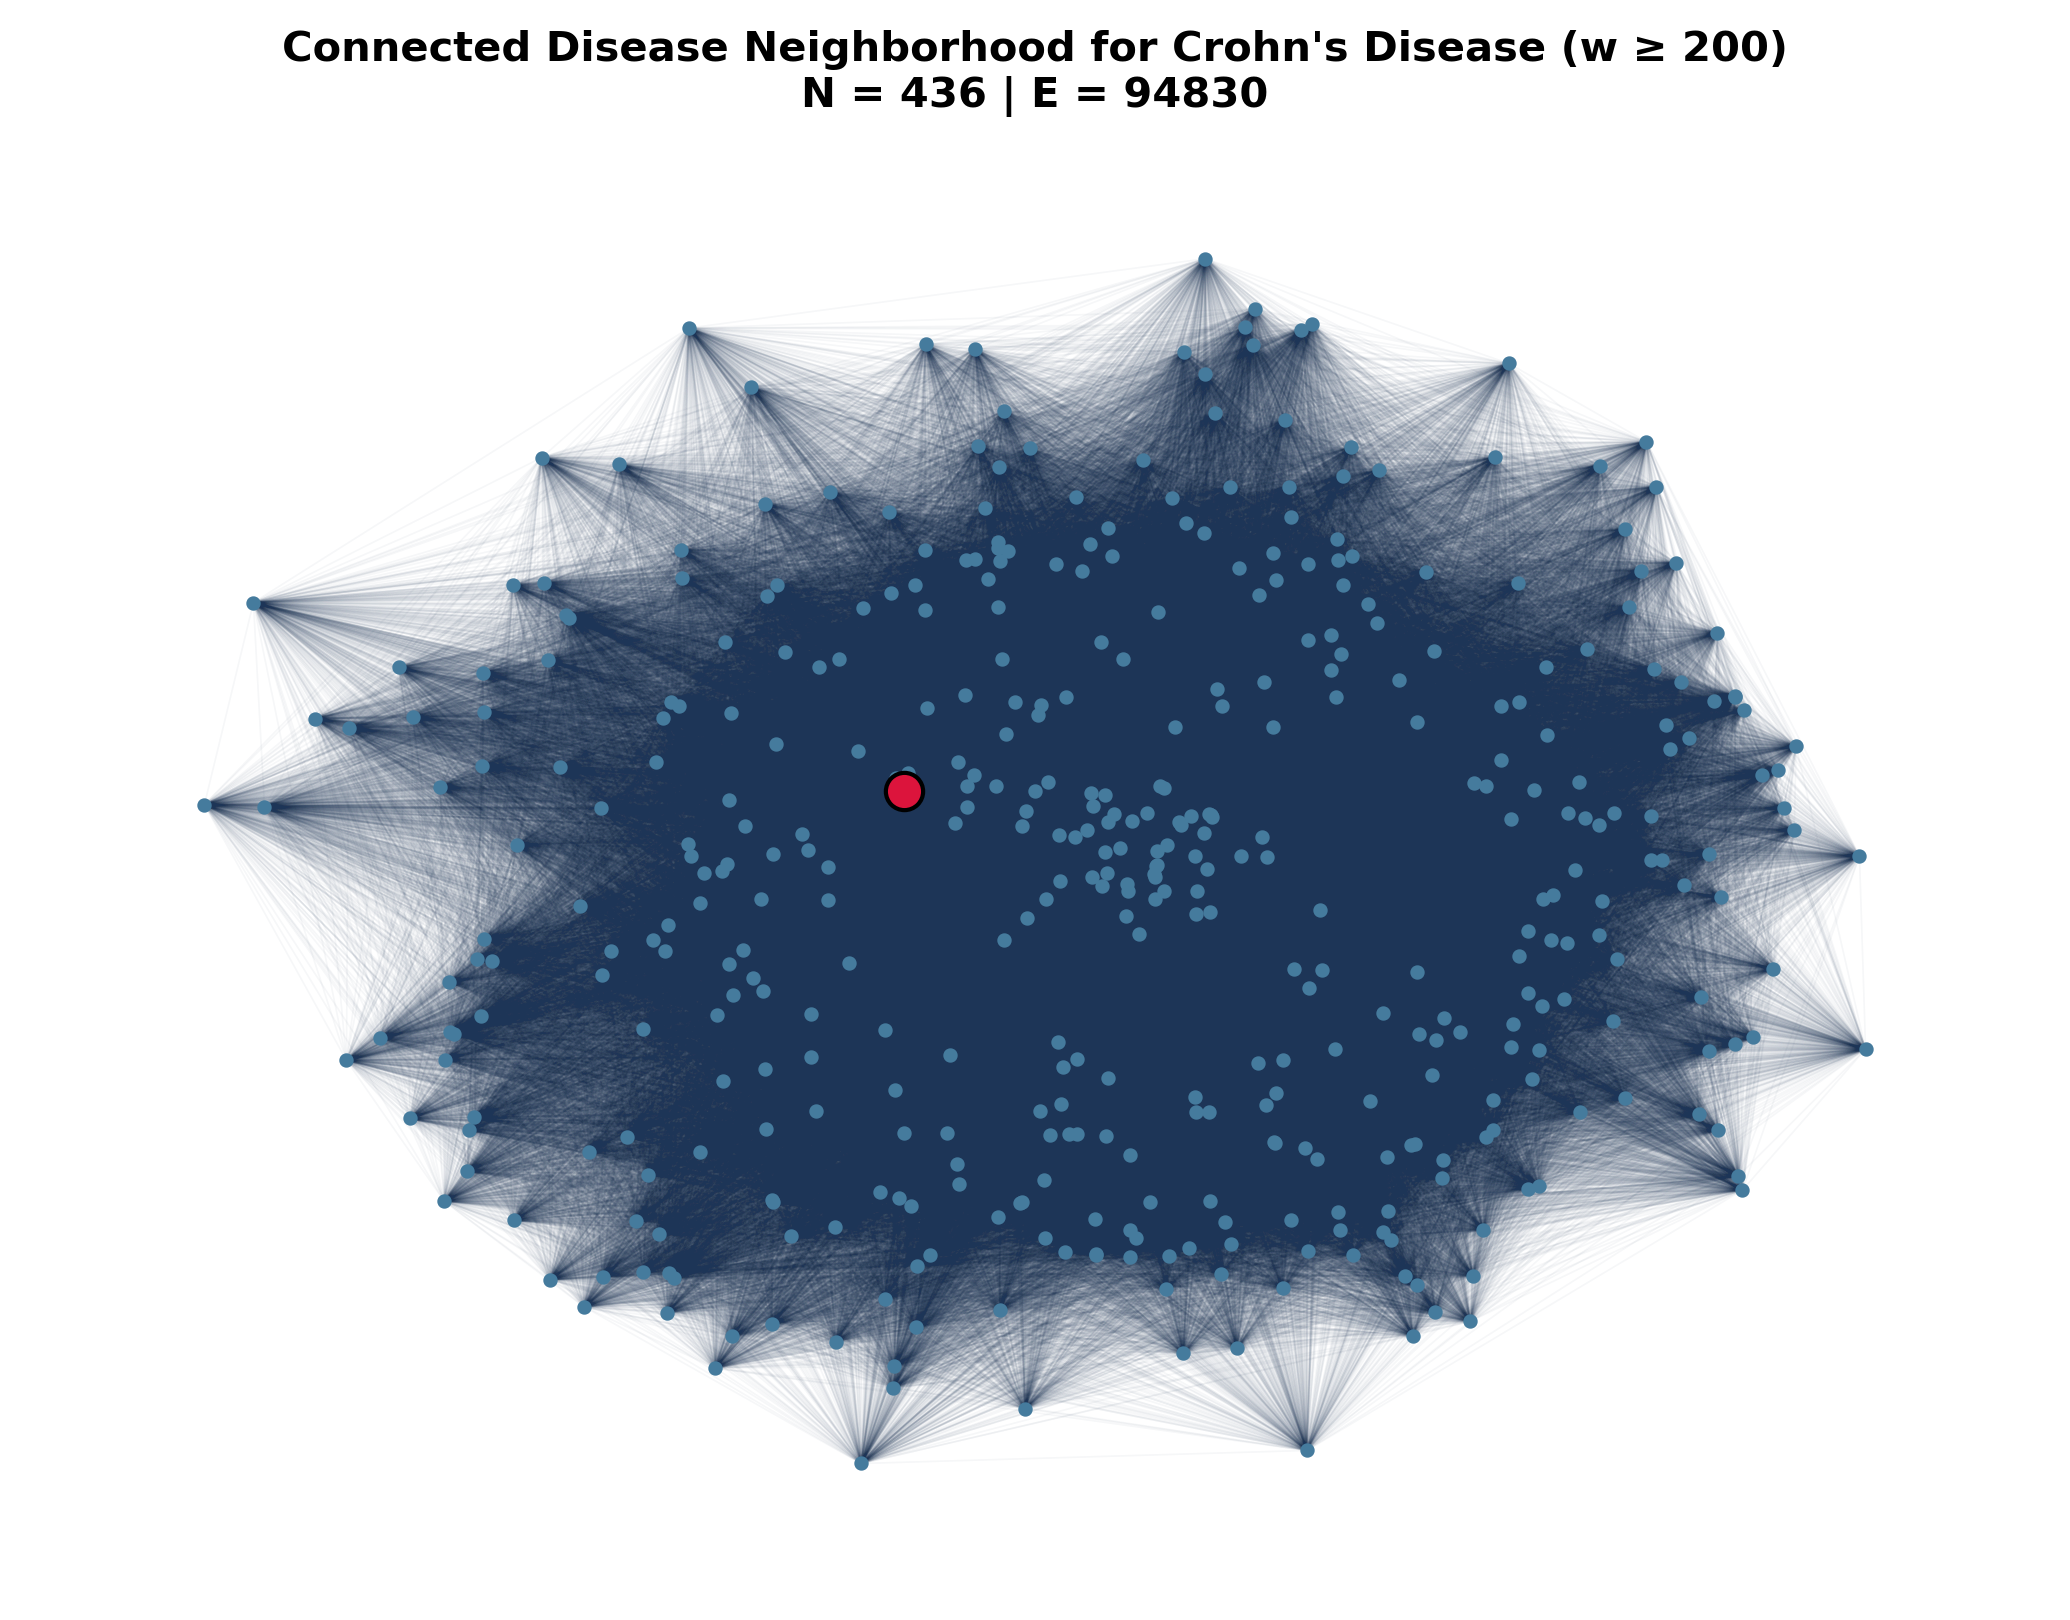

In [110]:
import matplotlib.pyplot as plt
import networkx as nx

fig, ax = plt.subplots(figsize=(7, 5.5), dpi=300)

# Layout: tight k to handle high node count cleanly
pos_crd = nx.spring_layout(sub_heavy_crd, seed=42, k=0.15)

# Edges: low alpha and narrow width to prevent a solid hairball
nx.draw_networkx_edges(
    sub_heavy_crd,
    pos_crd,
    ax=ax,
    alpha=0.04,
    width=0.4,
    edge_color="#1D3557",
)

# Background nodes: smaller size for the denser module
nx.draw_networkx_nodes(
    sub_heavy_crd,
    pos_crd,
    ax=ax,
    nodelist=[n for n in sub_heavy_crd if n != "MESH:D003424"],
    node_size=6,
    node_color="#457B9D",
)

# Focal node (Crohn's Disease)
nx.draw_networkx_nodes(
    sub_heavy_crd,
    pos_crd,
    ax=ax,
    nodelist=["MESH:D003424"],
    node_size=80,
    node_color="crimson",
    edgecolors="black",
)

ax.set_title(
    f"Connected Disease Neighborhood for Crohn's Disease (w ≥ 200)\nN = {sub_heavy_crd.number_of_nodes()} | E = {sub_heavy_crd.number_of_edges()}",
    fontsize=10,
    fontweight="bold",
)
ax.axis("off")

plt.tight_layout()
plt.savefig("Connected Disease Neighborhood for Crohn's Disease_I.png", dpi=300)
plt.show()

In [111]:
#Documented Gemini Prompt, discussing the differences between the two connected diseases neighborhood graphs

In [112]:
#first let's have a look at the number of GO terms associated originally with each disease

##To this end I consider the co-affiliation network B again
#(B = nx.from_pandas_edgelist(df_2, source="MESH_ID", target="GO_ID"))

#And...I apply again the method G.degree, which is returning the number of edges adjacent to each node in a graph
#https://networkx.org/documentation/stable/reference/classes/generated/networkx.Graph.degree.html

print("GO terms annotated to Celiac disease:", B.degree[cd_id], "| GO terms annotated to Crohn's disease:", B.degree[crd_id])


GO terms annotated to Celiac disease: 291 | GO terms annotated to Crohn's disease: 1475


In [113]:
#next, which is the number of neighbors in the ego graph extracted from G_proj and centered either on
#celiac disease or Crohn's disease?

In [114]:
#celiac disease
len(heavy_nodes) #does not include celiac disease

27

In [115]:
#Crohn's
len(heavy_nodes_crd) #does not include Crohn's

435

In [116]:
#This means that Crohn's disease has 435 neighbors at w≥200, celiac has only 27
#More precisely: only 27 diseases overlap with celiac disease GO-term profile by 200+ terms
#435 diseases overlap instead with Crohn's disease GO-term profile by 200+ terms.

#GO terms annotated to Crohn's disease are 1475. This makes the graph of course more dense...

#However, what drives the higher number of nodes/edges in Crohn's disease? (Especially in terms of direct links to each disease)

In [117]:
#to answer this question, let's check on pool size of neighbors in terms of GO annotations (still considering the weight threshold of 200)

In [118]:
#defining the pool size
pool_size = df_2.groupby("MESH_ID")["GO_ID"].nunique() #number of GO terms for every disease in the dataset

In [119]:
print(pool_size[heavy_nodes].median(),      # celiac's neighbors
pool_size[heavy_nodes_crd].median()) # Crohn's neighbors

3335.0 862.0


In [120]:
##pool size results

#Crohn's 435 neighbors have a smaller median pool (862) than celiac disease 27 neighbors (3335)
#meaning that-->
#the diseases that strongly overlap with celiac disease tend to have around 3335 GO terms each
#the diseases that strongly overlap with Crohn's disease tend to have around 862 GO terms each

#Celiac disease primarily exhibits high pathway overlap with other diseases
#possessing very large annotation pools (>3000 terms).
#Statistically, broader annotation sets capture celiac (specific) functional profile more "easily".
#This indicates that "partner diseases" must span a wide repertoire of GO terms to overlap heavily with celiac disease.
#This implies also that celiac disease has a distinct combination of GO terms which is substantially 
#very specific and rarer than Crohn's disease, ultimately resulting in a much lower network density. 
#Is this really the case? (see also Discussion in Report)

In [121]:
#shortest path lengths

#Platt (2019), Chapter 6
#Networks can be characterized according to their distribution of shortest path lengths
#what is a shortest path length?
#"a path between two nodes in a graph such that the total distance is minimized...", definition is in:
#https://networkx.org/documentation/stable/reference/algorithms/shortest_paths.html

In [122]:
#For this type of analysis I am going to use again the disease-disease network, DD-Miner
G = nx.from_pandas_edgelist(df, source="Disease1", target="Disease2")

In [123]:
#two key references for the next code cells
#https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.components.connected_components.html
#https://stackoverflow.com/questions/59695107/what-is-meant-by-largest-cc-in-graph

In [124]:
#Specifically, I intend to look at shortest path length using  nx.shortest_path_length in networkx

#in an unweighted graph like G above defined, this means "finding the path with the fewest number of edges", as stated in: 
#https://networkx.org/documentation/stable/reference/algorithms/shortest_paths.html

#on this matter, see also: https://medium.com/@jainsnehasj6/networkx-for-python-a-practical-guide-to-shortest-paths-and-minimum-spanning-trees-4809e5066596

#why this is interesting?

#In the comparison between celiac and Crohn's diseases, 
#this metric provides insight into the global relationship between an individual disease 
#and the rest of the network, defining its overall connectivity and a sort of 'reachability speed' across the taxonomic space

In [125]:
##To continue, I have to consider first of all two issues:

#what exactly Im going to use here, the "all" G? 
#and how to anchor the data to either celiac disease or crohn's disease -->


#Documented Gemini Prompt, shortest path length analysis

#first issue:

#this has to do with components in an undirected graph: 
#these are defined as a "connected subgraph that is not part of any larger connected subgraph", see next Wikipedia link
#https://en.wikipedia.org/wiki/Component_(graph_theory)
#Now, if two nodes sit in separate disconnected components, there is no sequence of edges connecting them
#so I have to make sure that the shortest path is always finite--> see next code


In [126]:
largest_cc = max(nx.connected_components(G), key=len) 
#by running this cell, I am "partitioning the graph into disjoint sets of nodes" and taking the biggest
#in this way I can compare celiac and crohn's disease for the metric of interest on the same largest and "analysis-feasable" component

#on connected components in networkx: 
#https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.components.connected_components.html

In [127]:
#it is here opportune instantiating a distinct, independent graph
G_connected = G.subgraph(largest_cc).copy() 

In [128]:
#second issue
#anchoring the data to the disease of interest

#this (and next) cell code adapted from Platt (2019), Chapter 6
#length_cd_target = dict(nx.shortest_path_length(G_connected))
#how to modify the code above so that I can "anchor" the data to celiac disease node?
#Documented Gemini Prompt, nested dictionary


length_cd_target = {
    "DOID:10608": dict(
        nx.shortest_path_length(G_connected, source="DOID:10608")
    )
}



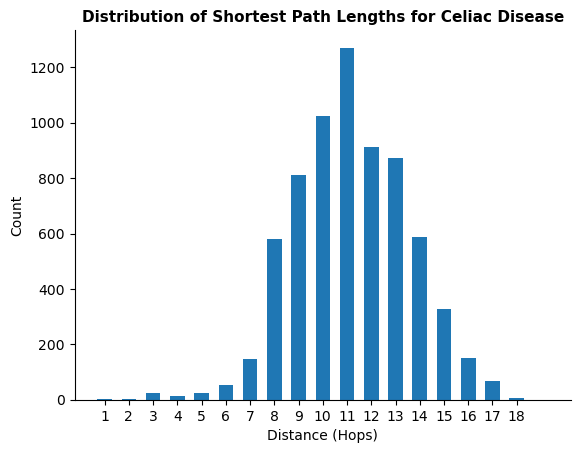

In [129]:
#Main reference: Platt (2019), Chapter 6
#Reference for sns.despine():
# https://www.tutorialspoint.com/seaborn/seaborn_despine_method.htm

import seaborn as sns

all_shortest_cd = [
    dist
    for target_dict in length_cd_target.values()
    for dist in target_dict.values()
    if dist > 0
]

high = max(all_shortest_cd) if all_shortest_cd else 1
bins = [0.5 + i for i in range(high + 2)]

plt.hist(all_shortest_cd, bins=bins, rwidth=0.6, color="#1f77b4")
plt.title("Distribution of Shortest Path Lengths for Celiac Disease", fontsize=11, fontweight="bold")
plt.xlabel("Distance (Hops)")
plt.ylabel("Count")
plt.xticks(range(1, high + 1))
sns.despine()

plt.savefig(
    "Distribution SPL Celiac.png",
    dpi=300,
    bbox_inches="tight",  
    pad_inches=0,         
                          
)

plt.show()

In [130]:
type(all_shortest_cd)

list

In [131]:
#now, let's retrieve the DOID "value" for Crohn's disease and replicate for Crohn's disease the same type of analysis
df_doid.loc[df_doid['Disease_Name']=="Crohn's disease"]
#DOID:8778

,DOID,Disease_Name
13633,DOID:8778,Crohn's disease


In [132]:
#nested/outer dictionary
length_crd_target = {
    "DOID:8778": dict(
        nx.shortest_path_length(G_connected, source="DOID:8778")
    )
}

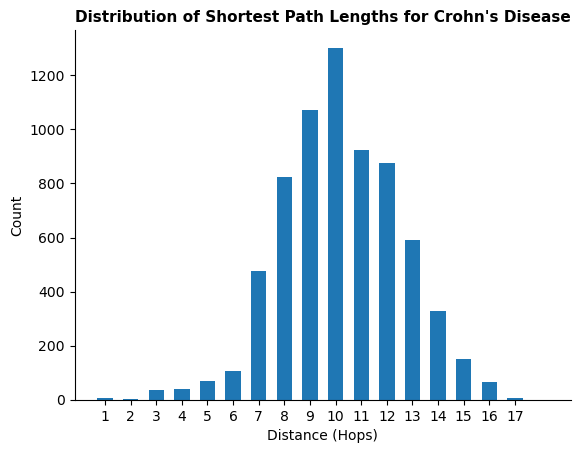

In [133]:
all_shortest_crd = [
    dist
    for target_dict in length_crd_target.values()
    for dist in target_dict.values()
    if dist > 0
]

high = max(all_shortest_crd) if all_shortest_crd else 1
bins = [0.5 + i for i in range(high + 2)]

plt.hist(all_shortest_crd, bins=bins, rwidth=0.6, color="#1f77b4")
plt.title("Distribution of Shortest Path Lengths for Crohn's Disease", fontsize=11, fontweight="bold")
plt.xlabel("Distance (Hops)")
plt.ylabel("Count")
plt.xticks(range(1, high + 1))
sns.despine()


plt.savefig(
    "Distribution SPL Crohn.png",
    dpi=300,
    bbox_inches="tight",  
    pad_inches=0,  
      
)

plt.show()

In [134]:
#Both distributions display nearly identical bell-shaped profiles
#peaking at comparable disease frequencies (1,271 for celiac vs. 1,302 for Crohn's disease- see next codes)

In [135]:
type(all_shortest_crd)

list

In [136]:
#https://stackoverflow.com/questions/27009247/find-min-max-and-average-of-a-list
import statistics
print("Celiac disease:", statistics.mean(all_shortest_cd), "Crohn's disease:", statistics.mean(all_shortest_crd))

Celiac disease: 11.177257525083611 Crohn's disease: 10.212592700305366


In [137]:
#how rapidly each condition accesses the rest of the medical ontology tree or taxonomic space?

# a rough evaluation of this is given by the reciprocal of calculated mean values
#this resembles the concept of closeness centrality as presented in Chapter 5, Platt (2019)

In [138]:
closeness_cd=1/(statistics.mean(all_shortest_cd))
round(closeness_cd,2)

0.09

In [139]:
closeness_crd=1/(statistics.mean(all_shortest_crd))
round(closeness_crd,2)

0.1

In [140]:
#other parameters of interest are following

In [141]:
print("Celiac disease:", statistics.mode(all_shortest_cd), "Crohn's disease:", statistics.mode(all_shortest_crd))
#value that appears most frequently in a dataset, 

Celiac disease: 11 Crohn's disease: 10


In [142]:
#histo highest peak values, celiac disease
#for celiac disease the most distance recurrent value is
mode_hops_cd=statistics.mode(all_shortest_cd) 
#how many times is counted this value?
all_shortest_cd.count(mode_hops_cd)

1271

In [143]:
#histo highest peak values, Crohn's disease
#for Crohn's disease the most distance recurrent value is
mode_hops_crd=statistics.mode(all_shortest_crd) 
#how many times is counted this value?
all_shortest_crd.count(mode_hops_crd)

1302

In [144]:
max(all_shortest_cd) 

18

In [145]:
max(all_shortest_crd)

17

In [146]:
len(all_shortest_cd) 
#numbers of nodes overall reached
#as shortest path lenghts are calculate on the same largest component, these values are
#expected to be the same

6877

In [147]:
len(all_shortest_crd) #as above

6877

In [148]:
#Although Crohn's and Celiac show a marked contrast in immediate heavy connectivity (435 vs. 27 high-weight partners at w≥200)
#their broader positions in the global taxonomy is comparable. 

In [149]:
display(Markdown("""
<span style="font-size:16px;">

### RQ 5

#### Enterovirus infections and celiac disease: how is this relationship structurally reflected in the ontological disease space?

"""))


<span style="font-size:16px;">

### RQ 5

#### Enterovirus infections and celiac disease: how is this relationship structurally reflected in the ontological disease space?



In [150]:
#Enteroviruses are increasingly considered candidate triggers for celiac disease (Kahrs et al., PMID: 30760441, Oikarinen et al., PMID: 33603739)

#Enterovirus infections may trigger the onset of celiac disease by altering for instance
#intestinal epithelial barrier integrity and dysregulating interferon signaling.
#Furthermore, evidence links infection to the activation of transglutaminase 2 (TG2),
#he primary enzyme driving the autoimmune response and mucosal damage.
#(Wells et al., PMID: 31117206, Bhunia et al., PMID: 36714092Le et al.,). 

#However, these molecular responses serve as both prerequisites and drivers 
#for celiac disease onset and progression. For instance, the disruption of 
#the epithelial barrier is a foundational mechanism underlying celiac disease
#(Cardoso-Silva et al., PMID: 31581491). See also Appendix 1. 

#This implies that enterovirus infections and celiac disease should share several GO terms.
#In the B network this relationship is thus hypothesized 
#to yield an elevated Jaccard similarity (at least relative to 
#unrelated conditions: i.e., negative controls).

#"Jaccard similarity is a statistical measure used to quantify how similar two sets are", as in 
#https://www.ibm.com/think/topics/jaccard-similarity
# or
#https://en.wikipedia.org/wiki/Jaccard_index

In [151]:
#Mesh of enterovirus infections (MESH:D004769)  
df_mesh_key[df_mesh_key["Disease_Name"].str.contains("Enterovirus", case=False, na=False)]

,MESH_ID,Disease_Name,Definitions
3627,MESH:D004769,Enterovirus Infections,NaN


In [152]:
#here I check on the number of GO terms shared by celiac disease and enterovirus infections, for this I use G_proj...
G_proj.get_edge_data("MESH:D002446", "MESH:D004769")
#Returns the attribute dictionary associated with edge (u, v), see also:
#https://networkx.org/documentation/stable/reference/classes/generated/networkx.Graph.get_edge_data.html

{'weight': 8}

In [153]:
#Celiac disease and enterovirus infections share exactly 8 GO biological processes
#unexpectedly low given the hypothesized viral trigger in celiac pathogenesis!

In [154]:
# Here I get the GO terms for each condition from the bipartite graph B
got_celiac = set(B.neighbors("MESH:D002446"))
got_entero = set(B.neighbors("MESH:D004769"))

# Then I extract the intersection (the 8 shared terms)
shared_cd_entero = got_entero.intersection(got_celiac)
#print("Count:", len(shared_cd_entero))
print(shared_cd_entero) 

{'GO:0016021', 'GO:0005524', 'GO:0005739', 'GO:0005887', 'GO:0005515', 'GO:0000166', 'GO:0016020', 'GO:0005886'}


In [155]:
type(shared_cd_entero) #nota bene: a set is an unordered collection of data types!
                       #https://www.geeksforgeeks.org/pandas/create-a-set-from-a-series-in-pandas/

set

In [156]:
#GOs present in my shared set
df_shared_info = df_go[df_go["GO"].isin(shared_cd_entero)]
df_shared_info

,GO,Biological Function
134,GO:0000166,nucleotide binding
7757,GO:0016020,membrane
13034,GO:0005515,protein binding
13043,GO:0005524,ATP binding
13233,GO:0005739,mitochondrion
19469,GO:0005886,plasma membrane


In [157]:
#initially I checked also on rotavirus infections, MESH:D012400
#which could act aslo as environmental triggers for celiac disease (Stene et al., PMID: 17032199)
#however, running this code raises an error:
#NetworkXError: The node MESH:D012400 is not in the graph.
#Therefore, this type of disease is not present 

#got_rota = set(B.neighbors("MESH:D012400"))

#shared_cd_rota = got_rota.intersection(got_celiac)

#print("Count:", len(shared_cd_rota))
#print(shared_cd_rota)

In [158]:
#here I select my negative controls 

In [159]:
#Documented Gemini Prompt, suggest and check on diseases etiologically unrelated to celiac disease 
cd_id = "MESH:D002446"

low_controls = {
    "Achondroplasia": "MESH:D000130",
    "Color Vision Defects": "MESH:D003117",
    "Strabismus": "MESH:D013328",
    "Otosclerosis": "MESH:D010041",
    "Osteogenesis Imperfecta": "MESH:D009976",
    "Motion Sickness": "MESH:D009033",
}

for name, mid in low_controls.items():
    in_g = G_proj.has_node(mid)
    has_edge = G_proj.has_edge(cd_id, mid) if in_g else False
    w = G_proj[cd_id][mid]["weight"] if has_edge else 0
    print(
        f"{name:<25} | In Graph: {in_g!s:<5} | Edge: {has_edge!s:<5} | Weight: {w}"
    )

Achondroplasia            | In Graph: True  | Edge: True  | Weight: 36
Color Vision Defects      | In Graph: True  | Edge: True  | Weight: 32
Strabismus                | In Graph: False | Edge: False | Weight: 0
Otosclerosis              | In Graph: False | Edge: False | Weight: 0
Osteogenesis Imperfecta   | In Graph: True  | Edge: True  | Weight: 13
Motion Sickness           | In Graph: False | Edge: False | Weight: 0


In [160]:
#jaccard_coefficient(G, ebunch=None), see
#https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.link_prediction.jaccard_coefficient.html

#ebunch:iterable of node pairs, optional (default = None)
#Jaccard coefficient will be computed for each pair of nodes given in the iterable. 
#The pairs must be given as 2-tuples (u, v) where u and v are nodes in the graph. 
#If ebunch is None then all nonexistent edges in the graph will be used. Default value: None.


In [161]:
#references for this cell
#https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.link_prediction.jaccard_coefficient.html
#https://stackoverflow.com/questions/74472110/how-to-save-result-of-for-loop-in-existing-input-dataframe

import networkx as nx

# test pairs (trigger vs negative controls)
cd_id = "MESH:D002446"
ebunch = [
    (cd_id, "MESH:D004769"),  # Enterovirus
    (cd_id, "MESH:D000130"),  # Achondroplasia
    (cd_id, "MESH:D003117"),  # Color Vision Defects
    (cd_id, "MESH:D009976"),  # Osteogenesis Imperfecta
]


preds = nx.jaccard_coefficient(B, ebunch)


results = []
for u, v, p in preds:
    print(f"({u}, {v}) -> {p:.8f}")
    results.append((u, v, p))  
df_jac = pd.DataFrame(results)

(MESH:D002446, MESH:D004769) -> 0.02515723
(MESH:D002446, MESH:D000130) -> 0.09944751
(MESH:D002446, MESH:D003117) -> 0.09580838
(MESH:D002446, MESH:D009976) -> 0.04012346


In [162]:
df_jac

,0,1,2
0,MESH:D002446,MESH:D004769,0.025157
1,MESH:D002446,MESH:D000130,0.099448
2,MESH:D002446,MESH:D003117,0.095808
3,MESH:D002446,MESH:D009976,0.040123


In [163]:
#I rearrange the dataframe
df_jac = df_jac.drop(columns=[0])
df_jac

,1,2
0,MESH:D004769,0.025157
1,MESH:D000130,0.099448
2,MESH:D003117,0.095808
3,MESH:D009976,0.040123


In [164]:
#assigning new column names
df_jac_1=df_jac.copy() 
df_jac_1.columns = ["MESH_ID", "Jaccard Index"]
df_jac_1

,MESH_ID,Jaccard Index
0,MESH:D004769,0.025157
1,MESH:D000130,0.099448
2,MESH:D003117,0.095808
3,MESH:D009976,0.040123


In [165]:
#df_mesh_key

In [166]:
#merging with df_mesh_key
df_merge_jac = df_jac_1.merge(
    df_mesh_key[["MESH_ID", "Disease_Name"]],
    on="MESH_ID",
    how="left"
)

df_merge_jac

,MESH_ID,Jaccard Index,Disease_Name
0,MESH:D004769,0.025157,Enterovirus Infections
1,MESH:D000130,0.099448,Achondroplasia
2,MESH:D003117,0.095808,Color Vision Defects
3,MESH:D009976,0.040123,Orthomyxoviridae Infections


In [167]:
#making a graph to visualize Jaccard values
import seaborn as sns

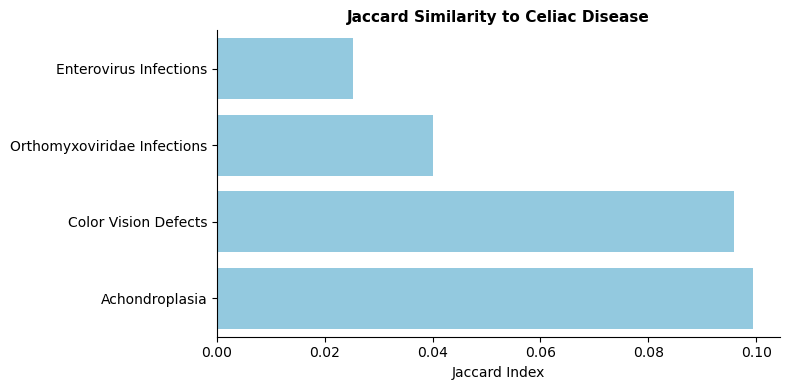

In [168]:
import matplotlib.pyplot as plt
import seaborn as sns

#to sort, see:
#https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_values.html
df_plot = df_merge_jac.sort_values(by="Jaccard Index", ascending=True)

# 2. Plot
plt.figure(figsize=(8, 4))
sns.barplot(data=df_plot, x="Jaccard Index", y="Disease_Name", color="skyblue")

plt.xlabel("Jaccard Index")
plt.ylabel("")
plt.title("Jaccard Similarity to Celiac Disease", fontsize=11, fontweight="bold")
plt.tight_layout()
sns.despine()

plt.savefig(
    "Jaccard Similarity to Celiac Disease.png",
    dpi=300,
    bbox_inches="tight",  
    pad_inches=0,  
      
)

plt.show()

In [169]:
#extracting again biological function common names from the GO terms of interest
df_shared_cd_ent_key = df_go[df_go["GO"].isin(shared_cd_entero)]
df_shared_cd_ent_key

,GO,Biological Function
134,GO:0000166,nucleotide binding
7757,GO:0016020,membrane
13034,GO:0005515,protein binding
13043,GO:0005524,ATP binding
13233,GO:0005739,mitochondrion
19469,GO:0005886,plasma membrane


In [170]:
df_shared_cd_ent_key.to_excel("Appendix _4_Entero Shared GO Terms.xlsx", index=False)

In [171]:
##The terms are essentially housekeeping functions, and not pathogenic signatures

In [172]:
#Overall, results show that the hypothesis of similarity between celiac disease and enterovirus infections as
#assesssed by the Jaccard index is not holding...(see also Discussion)